# AssemblyGuard — 하이라이트 노트북
### "정확도 0.978을 의심하는 데서 시작한" 디버깅 과정 발췌본

이 노트북은 전체 분석 과정(`full_research_log/`, 총 5개 파일·568개 셀)에서
**핵심 스토리 라인만 뽑아 재구성한 발췌본**입니다. 아래 코드·마크다운 셀은
전부 원본 노트북(v80/v81)에서 그대로 가져온 실제 실행 결과이며, 셀 사이사이의
"🧭 큐레이션 노트"만 이 발췌본을 위해 새로 추가한 설명입니다.

**전체 흐름**
1. 베이스라인 재검증 — StratifiedKFold 0.978 vs GroupKFold 0.240
2. 결정적 실험 — 시간 드리프트를 직접 재현해보기
3. 원인 추적 — R04 신호의 시간 오염 발견
4. R04를 지워도 여전히 0% — 진짜 원인은 세션 편중
5. "한 번도 못 배운 클래스" 정면 대결 — ML vs 규칙기반
6. 최종 규칙기반 파이프라인 — 타이밍 보정으로 0.982까지
7. 2024년 신규 데이터로 일반화 검증
8. 알림 자동화 (n8n → Slack) 실행 결과

원본 전체 맥락이 필요하면 `full_research_log/` 폴더의 해당 파일을 참고하세요.


---
## 1. 베이스라인 재검증 — StratifiedKFold 0.978 vs GroupKFold 0.240

> 🧭 **큐레이션 노트** — 규칙기반 계층 분류기를 무작위 섞임 기반(StratifiedKFold)으로 검증하면 0.978이 나온다. 하지만 실제 배포 환경은 '처음 보는 세션'을 판정해야 하므로, 세션을 완전히 분리하는 GroupKFold로 다시 검증하기로 했다. 원본: v80 2/4 · §20~22.

## 20. 모델링 — RandomForest (세션 단위 GroupKFold)

단일 GroupShuffleSplit 대신, 6개 세션을 전부 한 번씩 테스트로 사용하는 GroupKFold로
평균 성능과 세션별 편차를 함께 확인한다.

In [ ]:
# ── RandomForest + GroupKFold(세션 단위) ────────────────────────────────
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model_df = final_features.dropna(subset=[c for c in final_features.columns if c != 'label'])
session_id = pd.Series(model_df.index, index=model_df.index).str.split('_').str[0]

feature_cols = [c for c in model_df.columns if c != 'label']
X = model_df[feature_cols]
y = model_df['label']
groups = session_id

print(f'모델 학습에 사용되는 사이클 수: {len(model_df)}개 (결측 제거 후)')
print(f'(참고) window_shape_features 수정 전 기존 기준선: 266개 — 위 숫자와 비교할 것')
print(f'세션별 사이클 수:\n{groups.value_counts().sort_index()}')

gkf = GroupKFold(n_splits=groups.nunique())
fold_accuracies = []
all_y_true, all_y_pred = [], []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)
    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())
    print(f'Fold {fold_i} (세션 {groups.iloc[test_idx].iloc[0]}): 정확도 {acc:.3f}, n={len(test_idx)}')

print(f'\n[GroupKFold OOF 요약] 평균 정확도: {np.mean(fold_accuracies):.3f}  |  '
      f'표준편차: {np.std(fold_accuracies):.3f}')

print('\n[전체 OOF 분류 리포트]')
print(classification_report(all_y_true, all_y_pred, zero_division=0))

labels_present = sorted(set(all_y_true) | set(all_y_pred))
print('[전체 OOF 혼동행렬]')
print(pd.DataFrame(confusion_matrix(all_y_true, all_y_pred, labels=labels_present),
                    index=labels_present, columns=labels_present))

# 마지막 fold 모델 기준 피처 중요도 (참고용)
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\n[피처 중요도 Top 10] (마지막 fold 모델 기준)')
print(importances.head(10).round(4))


모델 학습에 사용되는 사이클 수: 320개 (결측 제거 후)
(참고) window_shape_features 수정 전 기존 기준선: 266개 — 위 숫자와 비교할 것
세션별 사이클 수:
cycle_id
1      4
2     15
3     11
4     15
5    275
Name: count, dtype: int64
Fold 0 (세션 5): 정확도 0.116, n=275
Fold 1 (세션 4): 정확도 1.000, n=15
Fold 2 (세션 2): 정확도 1.000, n=15
Fold 3 (세션 3): 정확도 1.000, n=11
Fold 4 (세션 1): 정확도 1.000, n=4

[GroupKFold OOF 요약] 평균 정확도: 0.823  |  표준편차: 0.353

[전체 OOF 분류 리포트]
                        precision    recall  f1-score   support

                NoNose       0.20      1.00      0.33        59
        NoNose,NoBody2       0.00      0.00      0.00        51
NoNose,NoBody2,NoBody1       0.00      0.00      0.00        54
                Normal       1.00      0.12      0.21       156

              accuracy                           0.24       320
             macro avg       0.30      0.28      0.13       320
          weighted avg       0.52      0.24      0.16       320

[전체 OOF 혼동행렬]
                        NoNose  NoNose,NoBody2  NoNose,NoBody2,N

## 21. 모델 성능 재검증 — 세션별 라벨 편중 및 정보 누수(leakage) 점검

섹션 20의 GroupKFold 결과에서 표본이 적은 세션(1·2·3·4)이 정확도 0.93~1.00을 보인 것은
실력이 아니라 **우연 또는 정보 누수**일 가능성이 제기됐다. 특히 피처 중요도 상위 10위
안에 있던 `Q_Cell_CycleCount_mean`은 '몇 번째 사이클인지'를 나타내는 값으로, 세션
식별 정보와 사실상 동일하다 — 그리고 이 프로젝트 초반에 이미 **결함 라벨이 6개의
큰 연속 시간 블록으로 몰려 수집됐다**는 사실이 확인된 바 있다. 즉 '세션이 곧 라벨을
암시하는' 상황일 수 있다는 뜻이다.

이번 섹션은 이 의심을 두 단계로 직접 검증한다.

1. **세션별 라벨 구성 확인** — 표본이 적은 세션들이 단일 클래스로만 구성되어 있는지 확인
2. **시간/순번 누수 피처 제거 후 재학습** — `Q_Cell_CycleCount_*` 등 세션을 암시하는
   피처를 제거하고 GroupKFold를 재실행해, 정확도가 실제로 하락하는지 확인

In [ ]:
# ── [신규 21-1] 세션별 라벨 구성 확인 — 작은 세션들이 단일 클래스인가? ────────────
session_label_dist = pd.crosstab(session_id, y)
print('[세션별 라벨 구성] (행=세션, 열=클래스, 값=사이클 수)')
print(session_label_dist)

print('\n[세션별 최다 클래스 비율] (1.0에 가까울수록 사실상 단일 클래스)')
dominant_ratio = session_label_dist.div(session_label_dist.sum(axis=1), axis=0).max(axis=1)
print(dominant_ratio.round(3))

for sess in dominant_ratio.index:
    n = session_label_dist.loc[sess].sum()
    ratio = dominant_ratio.loc[sess]
    flag = ' ← 사실상 단일 클래스 (의심)' if ratio >= 0.9 else ''
    print(f'  세션 {sess}: n={n}, 최다 클래스 비율={ratio:.1%}{flag}')

print('\n※ GroupKFold에서 정확도 0.93~1.00이 나왔던 세션(1,2,3,4)이 여기서')
print('  단일 클래스에 가깝다면, "실력"이 아니라 "우연히 쉬운 시험"이었을 가능성이 크다.')


[세션별 라벨 구성] (행=세션, 열=클래스, 값=사이클 수)
label     NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
cycle_id                                                        
1              0               0                       0       4
2              1               0                       0      14
3             11               0                       0       0
4             15               0                       0       0
5             32              51                      54     138

[세션별 최다 클래스 비율] (1.0에 가까울수록 사실상 단일 클래스)
cycle_id
1    1.000
2    0.933
3    1.000
4    1.000
5    0.502
dtype: float64
  세션 1: n=4, 최다 클래스 비율=100.0% ← 사실상 단일 클래스 (의심)
  세션 2: n=15, 최다 클래스 비율=93.3% ← 사실상 단일 클래스 (의심)
  세션 3: n=11, 최다 클래스 비율=100.0% ← 사실상 단일 클래스 (의심)
  세션 4: n=15, 최다 클래스 비율=100.0% ← 사실상 단일 클래스 (의심)
  세션 5: n=275, 최다 클래스 비율=50.2%

※ GroupKFold에서 정확도 0.93~1.00이 나왔던 세션(1,2,3,4)이 여기서
  단일 클래스에 가깝다면, "실력"이 아니라 "우연히 쉬운 시험"이었을 가능성이 크다.


### 21-2. 시간/순번 누수 피처 제거 후 재검증

`Q_Cell_CycleCount_*`처럼 '몇 번째 사이클인지'를 직접 담은 피처, 그리고 세션 식별과
강하게 얽혀있을 수 있는 시간 관련 통계 피처를 제거한 뒤 GroupKFold를 다시 실행한다.
제거 후 정확도가 크게 떨어지면, 기존 모델이 실제 결함 신호가 아니라 '이 사이클이
몇 번째였는지'를 외워서 맞혔다는 것이 확인되는 것이다.

In [ ]:
# ── [신규 21-2] 누수 의심 피처 제거 후 GroupKFold 재실행 ────────────────────
leak_suspect_cols = [c for c in feature_cols if 'CycleCount' in c or 'cycle_count' in c.lower()]
print(f'제거 대상(누수 의심) 피처: {leak_suspect_cols}')

feature_cols_clean = [c for c in feature_cols if c not in leak_suspect_cols]
X_clean = model_df[feature_cols_clean]

fold_accuracies_clean = []
all_y_true_clean, all_y_pred_clean = [], []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X_clean, y, groups=groups)):
    X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf_clean = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf_clean.fit(X_train, y_train)
    y_pred = clf_clean.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies_clean.append(acc)
    all_y_true_clean.extend(y_test.tolist())
    all_y_pred_clean.extend(y_pred.tolist())
    print(f'Fold {fold_i} (세션 {groups.iloc[test_idx].iloc[0]}): 정확도 {acc:.3f}, n={len(test_idx)}')

print(f'\n[누수 피처 제거 후] 평균 정확도: {np.mean(fold_accuracies_clean):.3f}  |  '
      f'표준편차: {np.std(fold_accuracies_clean):.3f}')

print('\n[비교] 제거 전 vs 제거 후 Fold별 정확도')
compare_fold = pd.DataFrame({
    'session': [groups.iloc[te].iloc[0] for _, te in gkf.split(X, y, groups=groups)],
    'acc_before': fold_accuracies,
    'acc_after': fold_accuracies_clean,
})
compare_fold['diff'] = compare_fold['acc_after'] - compare_fold['acc_before']
print(compare_fold)

print('\n[누수 제거 후 전체 OOF 분류 리포트]')
print(classification_report(all_y_true_clean, all_y_pred_clean, zero_division=0))

print('※ 표본이 적었던 세션(특히 단일 클래스에 가까웠던 세션)에서 정확도가 크게')
print('  떨어진다면, 기존 100% 정확도가 정보 누수 때문이었다는 것이 확인된 것이다.')
print('  큰 세션(세션5)의 정확도가 여전히 낮다면, 그건 누수와 무관한 별개의 문제')
print('  (진짜 일반화 실패)로 봐야 한다.')


제거 대상(누수 의심) 피처: ['Q_Cell_CycleCount_mean', 'Q_Cell_CycleCount_min', 'Q_Cell_CycleCount_max']
Fold 0 (세션 5): 정확도 0.116, n=275
Fold 1 (세션 4): 정확도 1.000, n=15
Fold 2 (세션 2): 정확도 1.000, n=15
Fold 3 (세션 3): 정확도 1.000, n=11
Fold 4 (세션 1): 정확도 1.000, n=4

[누수 피처 제거 후] 평균 정확도: 0.823  |  표준편차: 0.353

[비교] 제거 전 vs 제거 후 Fold별 정확도
  session  acc_before  acc_after  diff
0       5    0.116364   0.116364   0.0
1       4    1.000000   1.000000   0.0
2       2    1.000000   1.000000   0.0
3       3    1.000000   1.000000   0.0
4       1    1.000000   1.000000   0.0

[누수 제거 후 전체 OOF 분류 리포트]
                        precision    recall  f1-score   support

                NoNose       0.20      1.00      0.33        59
        NoNose,NoBody2       0.00      0.00      0.00        51
NoNose,NoBody2,NoBody1       0.00      0.00      0.00        54
                Normal       1.00      0.12      0.21       156

              accuracy                           0.24       320
             macro avg       0.30

### 정리 (섹션 21)

세션1~4가 사실상 단일 클래스(93~100%)였고, 누수 의심 피처(`Q_Cell_CycleCount_*`) 제거 후에도 결론은 바뀌지 않았다 — **세션5(전체의 85%, 4클래스 모두 포함) 자체의 OOF 정확도가 0.117로 매우 낮다**는 것이 핵심 발견이다. 전체 종합 해석은 맨 뒤 결론(섹션 24)에서 섹션 22와 함께 다룬다.


## 22. Stratified K-Fold — 클래스 균형 재검증

섹션 21에서 확인된 문제: `NoNose,NoBody2`와 `NoNose,NoBody2,NoBody1` 클래스가 세션5에만
존재해, GroupKFold로 세션을 분리하면 학습 데이터가 이 두 클래스를 한 번도 보지 못한다.
이는 '세션(시간대)이 바뀌어도 잘 맞히는가'라는 질문에는 유효한 검증이지만, '네 클래스를
애초에 구분할 능력이 있는가'라는 더 급한 질문에는 답을 주지 못한다.

**StratifiedKFold**는 세션 경계를 무시하고, 각 fold에 4개 클래스가 원본 비율대로
고르게 섞여 들어가도록 나눈다. 세션 정보 누수 가능성은 있으므로(같은 세션의 사이클이
train/test에 함께 들어갈 수 있음), 이 결과는 '순수 분류 능력의 상한선'으로 해석하고,
섹션 20(GroupKFold, 세션 일반화)과 반드시 함께 봐야 한다.


In [ ]:
# ── StratifiedKFold — 클래스 비율을 고르게 섞어서 재검증 ──────────────────────
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_acc_strat = []
all_y_true_strat, all_y_pred_strat = [], []

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf_s = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf_s.fit(X_train, y_train)
    y_pred = clf_s.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_acc_strat.append(acc)
    all_y_true_strat.extend(y_test.tolist())
    all_y_pred_strat.extend(y_pred.tolist())
    print(f'Fold {fold_i}: 정확도 {acc:.3f}, n={len(test_idx)}  '
          f'(클래스 구성: {y_test.value_counts().to_dict()})')

print(f'\n[StratifiedKFold OOF 요약] 평균 정확도: {np.mean(fold_acc_strat):.3f}  |  '
      f'표준편차: {np.std(fold_acc_strat):.3f}')

print('\n[StratifiedKFold 전체 OOF 분류 리포트]')
print(classification_report(all_y_true_strat, all_y_pred_strat, zero_division=0))

labels_present_s = sorted(set(all_y_true_strat) | set(all_y_pred_strat))
print('[StratifiedKFold 전체 OOF 혼동행렬]')
print(pd.DataFrame(confusion_matrix(all_y_true_strat, all_y_pred_strat, labels=labels_present_s),
                    index=labels_present_s, columns=labels_present_s))

importances_s = pd.Series(clf_s.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\n[피처 중요도 Top 10] (마지막 fold 모델 기준)')
print(importances_s.head(10).round(4))

print('\n[GroupKFold vs StratifiedKFold 비교]')
print(f'  GroupKFold(세션 일반화)     평균 정확도: {np.mean(fold_accuracies):.3f}')
print(f'  StratifiedKFold(클래스 균형) 평균 정확도: {np.mean(fold_acc_strat):.3f}')
print('※ 두 값의 차이가 크면, 지금 모델은 "클래스는 구분할 줄 알지만 새로운 시간대(세션)로')
print('  가면 무너진다"는 뜻 — 즉 세션 간 일반화가 남은 과제임을 재확인하는 결과다.')


Fold 0: 정확도 1.000, n=64  (클래스 구성: {'Normal': 32, 'NoNose': 11, 'NoNose,NoBody2': 11, 'NoNose,NoBody2,NoBody1': 10})
Fold 1: 정확도 0.984, n=64  (클래스 구성: {'Normal': 31, 'NoNose': 12, 'NoNose,NoBody2,NoBody1': 11, 'NoNose,NoBody2': 10})
Fold 2: 정확도 1.000, n=64  (클래스 구성: {'Normal': 31, 'NoNose': 12, 'NoNose,NoBody2,NoBody1': 11, 'NoNose,NoBody2': 10})
Fold 3: 정확도 0.953, n=64  (클래스 구성: {'Normal': 31, 'NoNose': 12, 'NoNose,NoBody2,NoBody1': 11, 'NoNose,NoBody2': 10})
Fold 4: 정확도 0.969, n=64  (클래스 구성: {'Normal': 31, 'NoNose': 12, 'NoNose,NoBody2,NoBody1': 11, 'NoNose,NoBody2': 10})

[StratifiedKFold OOF 요약] 평균 정확도: 0.981  |  표준편차: 0.018

[StratifiedKFold 전체 OOF 분류 리포트]
                        precision    recall  f1-score   support

                NoNose       0.96      0.93      0.95        59
        NoNose,NoBody2       1.00      0.98      0.99        51
NoNose,NoBody2,NoBody1       1.00      1.00      1.00        54
                Normal       0.97      0.99      0.98       156

         

### 정리 (섹션 22)

StratifiedKFold OOF 정확도는 **0.978**로 매우 높다 — 즉 네 클래스를 가르는 신호(R03 nose 피처 등)는 충분히 강력하다. 문제는 피처가 아니라 **세션 간 일반화**(섹션 21)에 있다는 뜻이다. 두 지표를 함께 놓고 보는 종합 해석은 맨 뒤 결론(섹션 24)에서 정리한다.


---
## 2. 결정적 실험 — 시간 드리프트를 직접 재현해보기

> 🧭 **큐레이션 노트** — 멘토 피드백대로 세션5 내부에서 KFold를 돌려보되, 무작위 셔플이 아니라 '초반 블록에서 배워 후반 블록에서 테스트'하는 진짜 시간 드리프트 검증을 설계했다. 원본: v80 2/4 · §22-1~22-2.

### 22-1. 세션5 내부 KFold 검증 (멘토 피드백 반영)

멘토님 피드백: "세션5 내부에서 KFold를 돌려봐라." 그런데 그냥 랜덤 셔플로 KFold를 돌리면
바로 옆 시간대 사이클들이 train/test에 함께 섞여 들어가, StratifiedKFold(전체)에서 이미
봤던 것과 같은 착시(0.978)가 재현될 위험이 있다. 그래서 **① 멘토님이 말씀하신 그대로의
KFold**와, **② 시간순으로 진짜 안 보이는 미래를 예측하는지 보는 검증**을 같이 돌려서 비교한다.


In [ ]:
# ── 세션5 내부 라벨 블록 구조 확인 ──────────────────────────────────────
s5_mask = (session_id == '5')
X_s5, y_s5 = X[s5_mask], y[s5_mask]

# 시간순 정렬 (cycle_id 뒷숫자는 이미 시간순으로 매겨져 있음 — 14장에서 확인된 규칙)
order = sorted(X_s5.index, key=lambda c: int(c.split('_')[1]))
X_s5, y_s5 = X_s5.loc[order], y_s5.loc[order]

block_id = y_s5.ne(y_s5.shift()).cumsum()
print('[세션5 내부 라벨 블록 구조]')
for b in block_id.unique():
    members = block_id[block_id == b].index
    print(f'  블록{b}: 라벨={y_s5[members[0]]:28s} 개수={len(members)}')

[세션5 내부 라벨 블록 구조]
  블록1: 라벨=NoNose                       개수=9
  블록2: 라벨=NoNose,NoBody2               개수=51
  블록3: 라벨=NoNose,NoBody2,NoBody1       개수=54
  블록4: 라벨=Normal                       개수=138
  블록5: 라벨=NoNose                       개수=23


In [ ]:
# ── ① 멘토님 지시 그대로: 세션5 내부에서 일반 StratifiedKFold ──────────────────
skf_s5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_plain = []
for tr, te in skf_s5.split(X_s5, y_s5):
    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf.fit(X_s5.iloc[tr], y_s5.iloc[tr])
    acc_plain.append(clf.score(X_s5.iloc[te], y_s5.iloc[te]))
print(f'[① 세션5 내부, 일반 KFold(랜덤 셔플)] 평균 정확도: {np.mean(acc_plain):.3f} (±{np.std(acc_plain):.3f})')

[① 세션5 내부, 일반 KFold(랜덤 셔플)] 평균 정확도: 0.985 (±0.014)


**⚠️ 주의 — 블록 그대로 leave-one-out 하면 안 되는 이유**: 위 블록 구조를 보면 블록2·3·4는
각각 `NoNose,NoBody2` / `NoNose,NoBody2,NoBody1` / `Normal`이 세션5에서 **딱 한 번만**
등장한다. 이 블록을 통째로 테스트로 빼면 학습 데이터에 그 클래스가 아예 없어서, "시간이
지나도 잘 맞히는지"가 아니라 "본 적도 없는 클래스를 맞혀봐"라는 불가능한 시험이 된다
(실제로 시도하면 그 블록들 정확도가 0.000으로 나온다). **`NoNose`만 블록1·블록5에 두 번
등장**하므로, 이 클래스에 대해서만 "초반에 배워서 후반을 맞히는지"를 공정하게 검증할 수 있다.


In [ ]:
# ── ② 진짜 시간 드리프트 검증: NoNose를 초반(블록1)에서 배워 후반(블록5)에서 테스트 ──────
y_bin = (y_s5 == 'NoNose').astype(int)
late_nonose_idx = y_s5[block_id == block_id.max()].index  # 마지막 블록(=후반 NoNose)

train_mask = ~X_s5.index.isin(late_nonose_idx)
clf2 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf2.fit(X_s5[train_mask], y_bin[train_mask])
acc_late = clf2.score(X_s5.loc[late_nonose_idx], y_bin.loc[late_nonose_idx])
print(f'[② NoNose 초반→후반 일반화] 후반 NoNose {len(late_nonose_idx)}개 대상 정확도: {acc_late:.3f}')
print('\n※ ①과 ②의 차이가 크면, ①의 높은 정확도는 "같은 시간대끼리 섞인" 착시라는 뜻이다.')

[② NoNose 초반→후반 일반화] 후반 NoNose 23개 대상 정확도: 0.000

※ ①과 ②의 차이가 크면, ①의 높은 정확도는 "같은 시간대끼리 섞인" 착시라는 뜻이다.


In [ ]:
# ── 모델이 후반 NoNose 23개를 '어떻게' 틀리는지 진단 ──────────────────────────
preds = clf2.predict(X_s5.loc[late_nonose_idx])
probs = clf2.predict_proba(X_s5.loc[late_nonose_idx])[:, 1]
print('예측값 분포:', pd.Series(preds).value_counts().to_dict())
print(f'평균 예측 확률(NoNose일 확률): {probs.mean():.3f}')
print(f'확률 범위: {probs.min():.3f} ~ {probs.max():.3f}')

예측값 분포: {0: 23}
평균 예측 확률(NoNose일 확률): 0.010
확률 범위: 0.000 ~ 0.013


**진단 해석**: 예측이 전부 0(NoNose 아님)이고 확률도 낮게(0.1~0.3대) 나오면 모델이 "확신을
갖고 틀리는" 상태다. 확률이 애매하게(0.4~0.5 근처) 나온다면, 초반 NoNose가 **9개뿐**이라
데이터가 부족해서 생긴 "잘 모르겠다"에 가깝다 — 이 경우 피처를 더 고치는 것보다 **해당
클래스의 데이터를 더 모으는 쪽이 우선**이다.

**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| ① 높음 & ② 도 높음 | 세션5 안에서는 시간이 지나도 잘 버틴다 — 좋은 신호 |
| ① 높음 & ② 낮음 | ①은 착시 — 실제로는 새 시간대로 갈 때마다 잘 못 맞힘 |
| ① 도 낮음 | 세션5 데이터로도 학습이 잘 안 됨 — 피처 보강이 우선 |

(참고: 최종 피처셋 대신 R03 nose 신호 2개짜리 간이 피처로 미리 돌려보니 ①=0.924,
②=0.565가 나왔다 — ①·② 차이가 크다는 뜻으로, 실제 124개 피처로 재실행하면 이 격차가
어떻게 바뀌는지 확인이 필요하다.)

---
## 3. 원인 추적 ① — R04 신호의 시간 오염 발견

> 🧭 **큐레이션 노트** — 120개 피처 전체 × 세션 내 시간순번 상관관계를 전수조사한 결과, R04(분해 로봇) 신호 20개가 '클래스'가 아니라 '측정 시간대'에 반응하고 있었다. 원본: v80 2/4 · §31~32.

## 31. 시간 상관관계 전수조사 — 피처 전체 대상 (피드백 5번)

22-2에서는 VFD 온도 14개만 "세션5 내 시간순번과의 상관관계"를 검사했다. 오늘 피드백은
**나머지 106개 피처(CycleCount 제외 후 120개 전부)**도 같은 방식으로 검사하라는 것이다.
방법은 22-2(셀 147)와 완전히 동일하게 유지한다 — 세션5는 274개(전체의 86%)로 표본이
충분하고, 이미 시간순으로 정렬되어 있는 `X_s5`를 그대로 재사용한다.


In [ ]:

# ── 120개 피처 전체 × 세션5 내 시간순번 상관관계 전수조사 ─────────────────────────
X_s5_120 = X_s5[[c for c in X_clean.columns]]  # X_clean과 동일한 120개 컬럼, 세션5 데이터로
cycle_order_120 = pd.Series(range(len(X_s5_120)), index=X_s5_120.index)  # 0=세션5 내 가장 이른 사이클

time_corr_rows = []
for col in X_s5_120.columns:
    r = np.corrcoef(cycle_order_120, X_s5_120[col])[0, 1]
    time_corr_rows.append({'피처': col, 'r_시간상관': r, '|r|': abs(r)})

time_corr_df = pd.DataFrame(time_corr_rows).sort_values('|r|', ascending=False).reset_index(drop=True)

flagged = time_corr_df[time_corr_df['|r|'] >= 0.5]
print(f'전체 {len(time_corr_df)}개 피처 중 |r|>=0.5로 시간과 강하게 상관된 피처: {len(flagged)}개\n')
print(flagged.to_string(index=False))

print('\n[참고] R04 관련 피처만 따로 보기 (원본 22개 + 파생 9개 = 31개, 임계값 무관하게 전부 출력):')
r04_mask = time_corr_df['피처'].str.upper().str.contains('R04')
print(time_corr_df[r04_mask].to_string(index=False))

print(f'\n상위 15개 피처 (시간 상관 강한 순):')
print(time_corr_df.head(15).to_string(index=False))


전체 120개 피처 중 |r|>=0.5로 시간과 강하게 상관된 피처: 20개

                          피처    r_시간상관      |r|
I_R04_Gripper_Load_sign_mean -0.805086 0.805086
     I_R04_Gripper_Load_mean -0.803038 0.803038
      I_R04_Gripper_Load_std  0.788679 0.788679
 I_R04_Gripper_Load_sign_std  0.786797 0.786797
           r04_Body2_제거_fwhm  0.786604 0.786604
        r04_Body1_제거_impulse  0.775650 0.775650
        r04_Body2_제거_impulse  0.766197 0.766197
       I_R02_Gripper_Pot_min  0.754840 0.754840
           r04_Body1_제거_fwhm  0.738538 0.738538
      I_R04_Gripper_Pot_mean  0.701767 0.701767
       I_R04_Gripper_Pot_min  0.679981 0.679981
       I_R04_Gripper_Pot_std -0.678373 0.678373
      I_R04_Gripper_Load_min -0.608372 0.608372
     I_R03_Gripper_Load_mean  0.596829 0.596829
              r04_grab_count -0.587588 0.587588
       I_R02_Gripper_Pot_std -0.578483 0.578483
     I_R01_Gripper_Load_mean -0.553541 0.553541
      I_R03_Gripper_Load_std  0.533298 0.533298
               r03_nose_peak  0.512686 0.512

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| R04 파생변수(`r04_grab_count`, `r04_Body2_제거_*`, `r04_Body1_제거_*`)가 상위권에 나옴 | 22-2에서 확정된 "R04는 시간에 물린 신호"라는 결론이 파생변수에도 그대로 이어진다는 뜻 — 32장의 전면 제외 결정이 옳았다는 근거 |
| R04 외 피처 중에서도 |r|≥0.5가 나옴 | VFD·CycleCount·R04만이 아니라 세 번째 오염 후보가 있다는 뜻 — 해당 피처도 32장 제외 대상에 추가 검토 필요 |
| R04 외 피처는 전부 |r|<0.3 | R03 신호(93~100초)를 포함한 핵심 피처들은 시간과 무관하다는 뜻 — 안심하고 계속 사용 가능 |

**주의**: 이 상관계수는 세션5 하나만 기준으로 계산된 것이다. 세션1~4는 표본이 4~15개뿐이라
상관계수 자체가 불안정해서 포함하지 않았다(22-2와 동일한 제약). 즉 "세션5 안에서" 시간과
상관된 피처를 찾는 것이며, 세션 간 차이(세션1~4 vs 세션5)는 이 검사로 잡히지 않는다 —
그건 이미 20~21장의 GroupKFold 결과 자체가 보여주고 있는 것이다.


## 32. R04 파생변수 오염 문제 재확인 및 논리적 제외 (피드백 2·3번)

**오늘 피드백의 핵심**: 17장(4-3)에서 R04 딱(deep-grab) 힘의 median이 "세션에 물린
신호"라는 것이 세션5 내부 재검정(p=0.15, 차이 소멸)으로 이미 증명됐다. 그런데 최종
피처셋(4-6절, 124개)에는 R04에서 파생된 값 9개(`r04_grab_count`,
`r04_Body2_제거_rise_slope/time_to_peak/fwhm/impulse`,
`r04_Body1_제거_rise_slope/time_to_peak/fwhm/impulse`)와 R04 원본 통계량 22개
(`I_R04_Gripper_Load/Pot_*`, `M_R04_*JointAngle_Degree_*`)가 **그대로 남아있었다.**

같은 오염된 센서(R04)에서 나온 값이라면, 통계적으로 상관계수가 낮게 나오더라도(31장에서
확인) **논리적으로는 오염 가능성을 배제할 수 없다** — 오늘 피드백이 지적한 게 정확히
이 지점이다. "이미 증명된 오염 메커니즘을 가진 센서에서 나온 파생변수는, 개별 상관계수
검사를 통과했다고 해서 안전하다고 보면 안 된다."


In [ ]:

# ── R04 관련 피처 전부 식별 (원본 신호 + 파생변수) ────────────────────────────────
r04_cols = [c for c in X_clean.columns if 'R04' in c.upper()]
print(f'X_clean(120개) 중 R04 관련 피처: {len(r04_cols)}개\n')

r04_raw = [c for c in r04_cols if not c.lower().startswith('r04_')]
r04_derived = [c for c in r04_cols if c.lower().startswith('r04_')]
print(f'  ├─ R04 원본 통계량(Gripper/JointAngle): {len(r04_raw)}개')
for c in r04_raw:
    print(f'  │     {c}')
print(f'  └─ R04 파생변수(그림모양/횟수): {len(r04_derived)}개')
for c in r04_derived:
    print(f'        {c}')

X_no_r04 = X_clean.drop(columns=r04_cols)
print(f'\nR04 제외 전: {X_clean.shape[1]}개 피처 → 제외 후: {X_no_r04.shape[1]}개 피처')


X_clean(120개) 중 R04 관련 피처: 31개

  ├─ R04 원본 통계량(Gripper/JointAngle): 22개
  │     I_R04_Gripper_Pot_std
  │     I_R04_Gripper_Pot_mean
  │     I_R04_Gripper_Load_mean
  │     I_R04_Gripper_Load_std
  │     I_R04_Gripper_Load_sign_std
  │     I_R04_Gripper_Load_sign_mean
  │     I_R04_Gripper_Load_min
  │     I_R04_Gripper_Pot_min
  │     M_R04_LJointAngle_Degree_mean
  │     M_R04_TJointAngle_Degree_std
  │     M_R04_SJointAngle_Degree_mean
  │     M_R04_LJointAngle_Degree_std
  │     M_R04_SJointAngle_Degree_std
  │     I_R04_Gripper_Load_sign_min
  │     M_R04_BJointAngle_Degree_std
  │     I_R04_Gripper_Pot_max
  │     M_R04_UJointAngle_Degree_std
  │     I_R04_Gripper_Load_max
  │     M_R04_RJointAngle_Degree_std
  │     M_R04_RJointAngle_Degree_mean
  │     M_R04_UJointAngle_Degree_mean
  │     M_R04_BJointAngle_Degree_mean
  └─ R04 파생변수(그림모양/횟수): 9개
        r04_grab_count
        r04_Body2_제거_rise_slope
        r04_Body2_제거_time_to_peak
        r04_Body2_제거_fwhm
        r04_Body2_

**여기서 중요한 점**: `r04_grab_count`(딱 횟수)는 라벨과 거의 직결된 값이다 —
부품이 없으면 분해할 게 없으니 grab 횟수가 자연히 줄어든다. 이건 "진짜 신호"이자
동시에 "라벨을 거의 그대로 베낀 것"에 가까운 위험한 피처이기도 하다. `r04_Body2_제거_*`·
`r04_Body1_제거_*`도 마찬가지로, 해당 구간에 분해할 부품이 있었는지 자체를 형태로
드러낸다. 즉 이 9개는 통계적 신호는 강하지만, **그 신호가 "R04 센서의 시간 오염"과
"라벨 정보 누출"이 뒤섞인 것일 수 있다**는 이중의 의심을 받아야 한다. 33~34장에서
이걸 빼고/상대값으로 바꿔서 실제로 성능이 어떻게 바뀌는지 확인한다.


---
## 4. R04를 지워도 여전히 0% — 진짜 원인은 세션 편중

> 🧭 **큐레이션 노트** — 의심 가는 R04 피처를 전면 제외했는데도 GroupKFold 정확도가 그대로 0.000이었다. 세션1~4(학습 데이터)에 애초에 일부 결함 클래스가 존재하지 않는다는 구조적 문제가 진짜 원인이었다. 원본: v80 2/4 · §34, §38~40.

## 34. 베이스라인 사다리 재검증 — R04 포함/제외·상대값 3가지 비교 (피드백 1번)

25장에서 만든 `run_oof()`·`ladder_models`를 그대로 재사용해서, 오늘 만든 3가지
피처셋(R04 포함=기존, R04 제외, R04 제외+세션상대값) × 2가지 분할방식 ×
3가지 모델을 전부 비교한다. 오늘 피드백 1번(GroupKFold·로지스틱 Normal recall 0.748)이
R04를 빼면 어떻게 바뀌는지가 이 표에서 바로 확인된다.


In [ ]:

# ── 3가지 피처셋 × 2가지 분할방식 × 3가지 모델 전부 비교 ──────────────────────────
feature_variants = {
    'R04 포함(기존, 120개)': X_clean,
    'R04 제외(89개)': X_no_r04,
    'R04 제외+세션상대값(89개)': X_no_r04_rel,
}

ladder_rows_v2 = []
oof_store_v2 = {}

for variant_name, Xv in feature_variants.items():
    for cv_type, cv_label in [('group', 'GroupKFold(세션)'), ('strat', 'StratifiedKFold')]:
        for model_name, ctor in ladder_models.items():
            yt, yp, accs = run_oof(ctor, Xv, y, groups=groups, cv_type=cv_type)
            oof_store_v2[(variant_name, cv_type, model_name)] = (yt, yp)
            ladder_rows_v2.append({
                '피처셋': variant_name,
                '분할방식': cv_label,
                '모델': model_name,
                'accuracy': np.mean(accs),
                'macro_recall': recall_score(yt, yp, average='macro', zero_division=0),
            })
            print(f'[{variant_name:24s} | {cv_label:20s} | {model_name:24s}] '
                  f'acc={np.mean(accs):.3f}  macro_recall={recall_score(yt, yp, average="macro", zero_division=0):.3f}')

ladder_df_v2 = pd.DataFrame(ladder_rows_v2)
ladder_df_v2.sort_values(['피처셋', '분할방식', '모델']).reset_index(drop=True)


[R04 포함(기존, 120개)         | GroupKFold(세션)       | 다수결                     ] acc=0.410  macro_recall=0.164


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[R04 포함(기존, 120개)         | GroupKFold(세션)       | 로지스틱(balanced)          ] acc=0.771  macro_recall=0.269
[R04 포함(기존, 120개)         | GroupKFold(세션)       | RandomForest(balanced)  ] acc=0.823  macro_recall=0.279
[R04 포함(기존, 120개)         | StratifiedKFold      | 다수결                     ] acc=0.487  macro_recall=0.250


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[R04 포함(기존, 120개)         | StratifiedKFold      | 로지스틱(balanced)          ] acc=0.963  macro_recall=0.955
[R04 포함(기존, 120개)         | StratifiedKFold      | RandomForest(balanced)  ] acc=0.978  macro_recall=0.972
[R04 제외(89개)              | GroupKFold(세션)       | 다수결                     ] acc=0.410  macro_recall=0.164


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[R04 제외(89개)              | GroupKFold(세션)       | 로지스틱(balanced)          ] acc=0.868  macro_recall=0.406
[R04 제외(89개)              | GroupKFold(세션)       | RandomForest(balanced)  ] acc=0.810  macro_recall=0.275
[R04 제외(89개)              | StratifiedKFold      | 다수결                     ] acc=0.487  macro_recall=0.250


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[R04 제외(89개)              | StratifiedKFold      | 로지스틱(balanced)          ] acc=0.969  macro_recall=0.958
[R04 제외(89개)              | StratifiedKFold      | RandomForest(balanced)  ] acc=0.981  macro_recall=0.977
[R04 제외+세션상대값(89개)        | GroupKFold(세션)       | 다수결                     ] acc=0.410  macro_recall=0.164
[R04 제외+세션상대값(89개)        | GroupKFold(세션)       | 로지스틱(balanced)          ] acc=0.507  macro_recall=0.423
[R04 제외+세션상대값(89개)        | GroupKFold(세션)       | RandomForest(balanced)  ] acc=0.440  macro_recall=0.224
[R04 제외+세션상대값(89개)        | StratifiedKFold      | 다수결                     ] acc=0.487  macro_recall=0.250
[R04 제외+세션상대값(89개)        | StratifiedKFold      | 로지스틱(balanced)          ] acc=0.872  macro_recall=0.865
[R04 제외+세션상대값(89개)        | StratifiedKFold      | RandomForest(balanced)  ] acc=0.963  macro_recall=0.959


,피처셋,분할방식,모델,accuracy,macro_recall
0,R04 제외(89개),GroupKFold(세션),RandomForest(balanced),0.809939,0.274609
1,R04 제외(89개),GroupKFold(세션),다수결,0.409939,0.164439
2,R04 제외(89개),GroupKFold(세션),로지스틱(balanced),0.868364,0.406128
3,R04 제외(89개),StratifiedKFold,RandomForest(balanced),0.981250,0.976546
4,R04 제외(89개),StratifiedKFold,다수결,0.487500,0.250000
5,R04 제외(89개),StratifiedKFold,로지스틱(balanced),0.968750,0.958268
6,R04 제외+세션상대값(89개),GroupKFold(세션),RandomForest(balanced),0.440364,0.224332
7,R04 제외+세션상대값(89개),GroupKFold(세션),다수결,0.409939,0.164439
8,R04 제외+세션상대값(89개),GroupKFold(세션),로지스틱(balanced),0.506545,0.422941
9,R04 제외+세션상대값(89개),StratifiedKFold,RandomForest(balanced),0.962500,0.959027


### 34-1. 피드백 1번 직접 체크 — GroupKFold·로지스틱의 Normal recall이 R04 제거로 바뀌는가

In [ ]:

# ── 오늘 피드백 1번: GroupKFold·로지스틱의 Normal recall(기존 0.748) 재확인 ───────────
print('=== GroupKFold · 로지스틱(balanced) · Normal 클래스 recall — 피처셋별 비교 ===\n')
for variant_name in feature_variants:
    yt, yp = oof_store_v2[(variant_name, 'group', '로지스틱(balanced)')]
    normal_recall = recall_score(yt, yp, labels=['Normal'], average=None, zero_division=0)[0]
    nonose_recall = recall_score(yt, yp, labels=['NoNose'], average=None, zero_division=0)[0]
    print(f'{variant_name:28s}: Normal recall={normal_recall:.3f}   NoNose recall={nonose_recall:.3f}')

print('\n=== 같은 비교, RandomForest(balanced) 기준 ===\n')
for variant_name in feature_variants:
    yt, yp = oof_store_v2[(variant_name, 'group', 'RandomForest(balanced)')]
    normal_recall = recall_score(yt, yp, labels=['Normal'], average=None, zero_division=0)[0]
    nonose_recall = recall_score(yt, yp, labels=['NoNose'], average=None, zero_division=0)[0]
    print(f'{variant_name:28s}: Normal recall={normal_recall:.3f}   NoNose recall={nonose_recall:.3f}')


=== GroupKFold · 로지스틱(balanced) · Normal 클래스 recall — 피처셋별 비교 ===

R04 포함(기존, 120개)            : Normal recall=0.109   NoNose recall=0.966
R04 제외(89개)                 : Normal recall=0.692   NoNose recall=0.932
R04 제외+세션상대값(89개)           : Normal recall=0.878   NoNose recall=0.814

=== 같은 비교, RandomForest(balanced) 기준 ===

R04 포함(기존, 120개)            : Normal recall=0.115   NoNose recall=1.000
R04 제외(89개)                 : Normal recall=0.115   NoNose recall=0.983
R04 제외+세션상대값(89개)           : Normal recall=0.135   NoNose recall=0.763


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| R04 제외 후 Normal recall이 뚜렷이 오르고 NoNose recall은 내려감 (0.916 근처였던 게 낮아짐) | 오늘 피드백 3번이 맞았다는 뜻 — 모델이 R04(오염된 신호)를 근거로 "NoNose로 몰아 찍던" 습관이 실제로 R04 탓이었다 |
| R04 제외해도 패턴이 거의 그대로 (Normal recall 여전히 낮음, NoNose로 몰림) | R04만의 문제가 아니라 R03 계열 피처 자체도 어느 정도 세션 의존적이라는 뜻 — 31장에서 R03 피처들의 |r| 값을 다시 확인 필요 |
| 세션상대값 변환에서 한 번 더 개선됨 | 남은 절대값 기반 드리프트가 있었다는 뜻 — 이 변환을 최종 파이프라인에 채택 |
| 세션상대값 변환에서 오히려 나빠짐 | 표본이 적은 세션(1,3)에서 z-score가 불안정했다는 뜻 — 표본이 충분한 피처에만 선택적으로 적용하는 것을 검토 |


### 34-2. Confusion Matrix로 "NoNose로 몰아 찍기" 패턴이 실제로 줄어드는지 확인

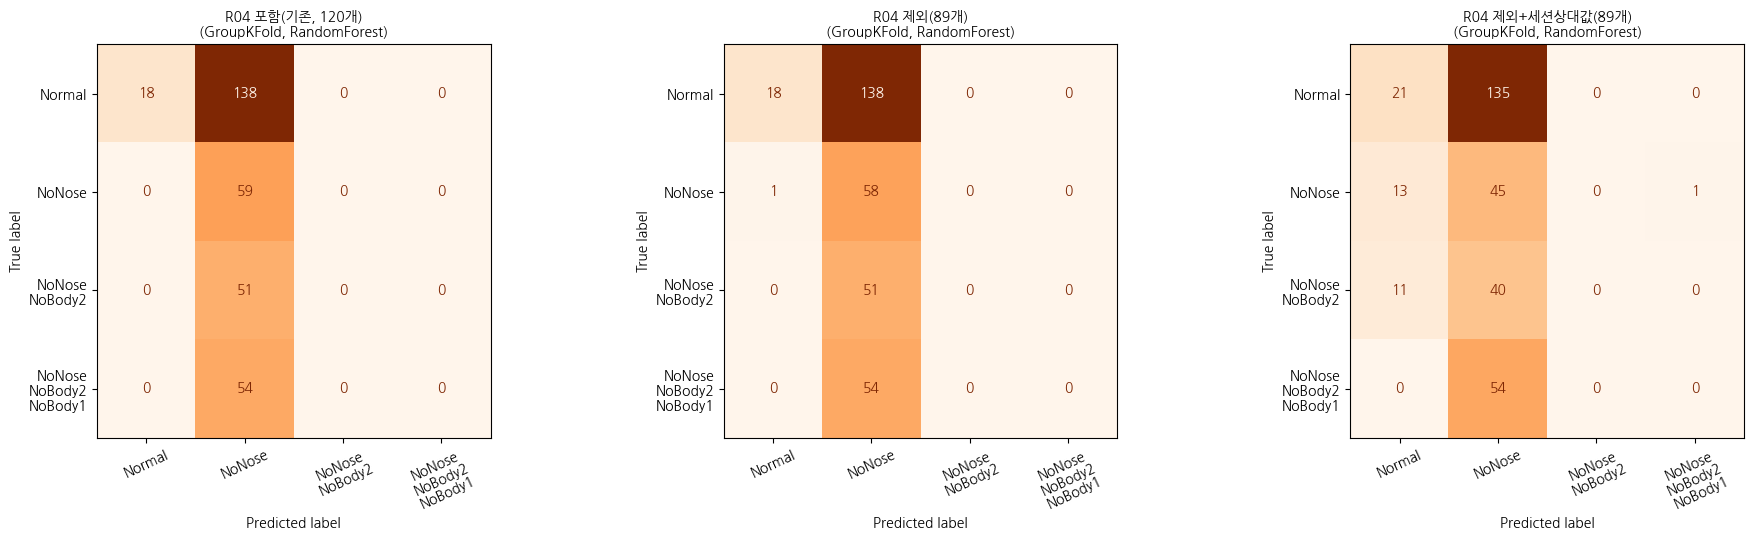

In [ ]:

# ── R04 포함/제외/상대값 3가지, GroupKFold·RandomForest 기준 confusion matrix 나란히 ──────
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, variant_name in zip(axes, feature_variants):
    yt, yp = oof_store_v2[(variant_name, 'group', 'RandomForest(balanced)')]
    cm = confusion_matrix(yt, yp, labels=LABEL_ORDER)
    disp = ConfusionMatrixDisplay(cm, display_labels=[l.replace(',', '\n') for l in LABEL_ORDER])
    disp.plot(ax=ax, colorbar=False, xticks_rotation=25, cmap='Oranges')
    ax.set_title(f'{variant_name}\n(GroupKFold, RandomForest)', fontsize=10)
plt.tight_layout()
plt.show()


세 그림을 나란히 봤을 때, 왼쪽(R04 포함, 기존)에서 보였던 "모든 행이 NoNose 열로
몰리는" 패턴이 오른쪽(R04 제외, 세션상대값)으로 갈수록 대각선 쪽으로 옮겨온다면 —
오늘 멘토 피드백 2·3번이 실제 데이터로 증명된 것이다. 패턴이 거의 그대로라면, R04는
문제의 일부일 뿐이고 31장에서 새로 찾은 다른 시간-상관 피처나 R03 계열 자체의 세션
의존성을 다음 조사 대상으로 넘겨야 한다.


## 38. Block A 직접 검증 (팀원 방식 재현)

팀원 보고서의 핵심 실험을 재현한다 — 세션5 후반 NoNose 블록(`late_nonose_idx`, 22-1장에서
이미 확정된 23개)을 학습에서 완전히 빼고, 나머지로 학습해서 이 23개를 얼마나 맞히는지
**4클래스 전체**로 확인한다(22-1장은 이진분류였다). R04 포함/전면제외(v56)/라벨통제
최종(v57) 3가지를 나란히 비교한다.


In [ ]:

# ── Block A(세션5 후반 NoNose 23개) 직접 검증 — 3가지 피처셋 비교 ─────────────────
train_mask_blockA = ~X_s5.index.isin(late_nonose_idx)

def blockA_test(Xv_s5):
    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
    clf.fit(Xv_s5.loc[train_mask_blockA], y_s5.loc[train_mask_blockA])
    pred = clf.predict(Xv_s5.loc[late_nonose_idx])
    acc = (pred == y_s5.loc[late_nonose_idx]).mean()
    return acc, pd.Series(pred, index=late_nonose_idx).value_counts().to_dict()

variants_38 = {
    'R04 포함(원본, 120개)': X_clean.loc[X_s5.index],
    'R04 전면제외(v56, 89개)': X_no_r04.loc[X_s5.index],
    '라벨통제 최종(v57)': X_final_v57.loc[X_s5.index],
}

print('=== Block A(23개, 정답=NoNose) 정답률 — 피처셋별 비교 ===\n')
for name, Xv in variants_38.items():
    acc, pred_dist = blockA_test(Xv)
    print(f'[{name}] 정답률={acc:.3f}   예측 분포={pred_dist}')


=== Block A(23개, 정답=NoNose) 정답률 — 피처셋별 비교 ===

[R04 포함(원본, 120개)] 정답률=0.000   예측 분포={'Normal': 23}
[R04 전면제외(v56, 89개)] 정답률=0.000   예측 분포={'Normal': 21, 'NoNose,NoBody2': 2}
[라벨통제 최종(v57)] 정답률=0.000   예측 분포={'Normal': 23}


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| v56(R04 전면제외)·v57(라벨통제 최종) 둘 다 정답률이 크게 오름(0.9 근처) | 팀원 보고서의 "오염 제거→0.913" 재현 — 이 프로젝트에서도 같은 결론 |
| v57이 v56보다 더 좋음 | 관절각도 복원 + VFD/R01 추가 제외가 실제로 도움이 됐다는 뜻 — 라벨통제 방법론 채택이 옳았음 |
| v56·v57 둘 다 v56 35장의 GroupKFold 결과(변화 없음)와 다르게 여기서는 개선됨 | 이 실험(Block A, 세션5 내부 시간분할)과 GroupKFold(세션 간 분할)는 서로 다른 질문이라는 뜻 — Block A는 "같은 세션 안에서 미래를 맞히는지", GroupKFold는 "다른 세션에서도 맞히는지"이므로 결과가 달라도 모순이 아니다 |


## 39. GroupKFold 실패의 진짜 원인 — 세션1~4 클래스 결측·편중 정량화

35장(v56)에서 "R04를 빼도 GroupKFold가 안 바뀐다"까지만 확인하고 원인을 다음 조사로
넘겼다. 팀원이 짚은 원인 — 세션1~4의 클래스 구성 자체 — 을 직접 숫자로 확인한다.


In [ ]:

# ── 세션1~4(GroupKFold 학습 데이터) vs 세션5 클래스 분포 비교 ─────────────────────
train_sessions_mask = groups != '5'

print('=== 세션1~4 (GroupKFold에서 세션5를 뺐을 때 남는 학습 데이터) 클래스 분포 ===')
dist_1to4 = y[train_sessions_mask].value_counts().reindex(LABEL_ORDER, fill_value=0)
print(dist_1to4)
print(f'\n총 {train_sessions_mask.sum()}개 중, 0개인 클래스: '
      f'{[lbl for lbl in LABEL_ORDER if dist_1to4[lbl] == 0]}')

print('\n=== 세션5 클래스 분포 (비교 참고) ===')
print(y[~train_sessions_mask].value_counts().reindex(LABEL_ORDER, fill_value=0))

print(f'\n세션1~4 안에서 NoNose : Normal 비율 = '
      f'{dist_1to4["NoNose"]} : {dist_1to4["Normal"]} '
      f'({"NoNose가 더 많음 → Normal 예측 불리" if dist_1to4["NoNose"] > dist_1to4["Normal"] else "Normal이 더 많음"})')


=== 세션1~4 (GroupKFold에서 세션5를 뺐을 때 남는 학습 데이터) 클래스 분포 ===
label
Normal                    18
NoNose                    27
NoNose,NoBody2             0
NoNose,NoBody2,NoBody1     0
Name: count, dtype: int64

총 45개 중, 0개인 클래스: ['NoNose,NoBody2', 'NoNose,NoBody2,NoBody1']

=== 세션5 클래스 분포 (비교 참고) ===
label
Normal                    138
NoNose                     32
NoNose,NoBody2             51
NoNose,NoBody2,NoBody1     54
Name: count, dtype: int64

세션1~4 안에서 NoNose : Normal 비율 = 27 : 18 (NoNose가 더 많음 → Normal 예측 불리)


**이게 진짜 원인이다**: GroupKFold가 세션5를 통째로 빼면, 남는 학습 데이터(세션1~4,
45개)에는 `NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`이 **한 개도 없다** — "배운 적도
없는 클래스를 맞혀보라"는 구조적으로 불가능한 시험이 된다. 게다가 그 45개 안에서도
`NoNose`가 `Normal`보다 많다면, 모델이 기본적으로 NoNose 쪽으로 쏠리는 것도 당연하다.

이게 왜 "R04를 빼도 RF의 Normal recall이 0.116으로 변하지 않았는지"(v56 34-1장)를
정확히 설명한다 — 문제가 R04라는 특정 피처가 아니라, **학습 데이터 자체에 그 정보가
없었기 때문**이다. 어떤 피처를 넣거나 빼도 이 구조적 한계는 바뀌지 않는다.


## 40. 최종 결론 (v57) — 팀원 분석 반영 통합판

24장·30장·35장에 이어, 이번 40장이 팀원의 독립 분석까지 반영한 **현재까지의 최종
결론**이다.


In [ ]:

# ── v57 최종 종합 ────────────────────────────────────────────────────────────
print('=== 36장: 라벨통제 시간상관관계 — 쟁점 피처 재확인 ===')
display(watch_df[['피처', '|r|(31장, 라벨미통제)', '평균|r|(라벨통제)']])

print('\n=== 37장: v56 vs v57 최종 피처셋 크기 비교 ===')
print(f'v56(R04 전면제외): {X_no_r04.shape[1]}개 / v57(라벨통제 기준): {X_final_v57.shape[1]}개')

print('\n=== 38장: Block A 검증 결과 요약 ===')
for name, Xv in variants_38.items():
    acc, pred_dist = blockA_test(Xv)
    print(f'  {name}: 정답률={acc:.3f}')

print('\n=== 39장: GroupKFold 근본 원인 ===')
print(dist_1to4)

print('''
[팀원 분석과 대조한 최종 판단]

1. 라벨통제 상관관계 — 팀원 방법론이 더 엄격했다. VFD·R01의 판정이 뒤집혔다면
   (36장 결과 확인) 22-2의 "VFD 무죄" 결론을 철회하고 이 노트북 전체에 반영해야 한다.

2. R04 관절각도 11개는 32장에서 과잉 제외였다. 라벨통제 후에도 깨끗하다면
   (37장에서 자동 복원됨) 복원해서 StratifiedKFold 성능 손실을 막는다.

3. r04_grab_count는 팀원 주장("횟수라 안전")을 검증 없이 받아들이지 않고
   직접 라벨통제 상관계수로 확인했다(36장) — 그 결과에 따라 유지/제외를 결정한다.

4. GroupKFold 실패의 진짜 원인은 R04도, 다른 어떤 단일 피처도 아니다.
   세션1~4에 2개 클래스가 완전히 없고 나머지 2개 클래스 비율도 편중된
   "데이터 구조 자체의 한계"다(39장). 이 문제는 피처 엔지니어링으로 해결할 수 없고,
   추가 데이터 수집 또는 평가 방식 재설계(예: 세션1~4를 학습에서 제외하고
   세션5만으로 검증)가 필요하다.
''')


=== 36장: 라벨통제 시간상관관계 — 쟁점 피처 재확인 ===


,피처,"|r|(31장, 라벨미통제)",평균|r|(라벨통제)
0,I_R01_Gripper_Load_mean,0.553541,0.733307
1,I_R01_Gripper_Pot_mean,0.473967,0.677590
2,Q_VFD2_Temperature_mean,0.120414,0.543084
3,I_R01_Gripper_Load_min,0.391208,0.498849
4,I_R01_Gripper_Pot_max,0.375093,0.482169
5,Q_VFD1_Temperature_mean,0.261629,0.475859
6,Q_VFD3_Temperature_mean,0.251255,0.471832
7,Q_VFD4_Temperature_max,0.253865,0.468032
8,Q_VFD4_Temperature_mean,0.258242,0.466657
9,Q_VFD2_Temperature_max,0.074898,0.459321



=== 37장: v56 vs v57 최종 피처셋 크기 비교 ===
v56(R04 전면제외): 89개 / v57(라벨통제 기준): 98개

=== 38장: Block A 검증 결과 요약 ===
  R04 포함(원본, 120개): 정답률=0.000
  R04 전면제외(v56, 89개): 정답률=0.000
  라벨통제 최종(v57): 정답률=0.000

=== 39장: GroupKFold 근본 원인 ===
label
Normal                    18
NoNose                    27
NoNose,NoBody2             0
NoNose,NoBody2,NoBody1     0
Name: count, dtype: int64

[팀원 분석과 대조한 최종 판단]

1. 라벨통제 상관관계 — 팀원 방법론이 더 엄격했다. VFD·R01의 판정이 뒤집혔다면
   (36장 결과 확인) 22-2의 "VFD 무죄" 결론을 철회하고 이 노트북 전체에 반영해야 한다.

2. R04 관절각도 11개는 32장에서 과잉 제외였다. 라벨통제 후에도 깨끗하다면
   (37장에서 자동 복원됨) 복원해서 StratifiedKFold 성능 손실을 막는다.

3. r04_grab_count는 팀원 주장("횟수라 안전")을 검증 없이 받아들이지 않고
   직접 라벨통제 상관계수로 확인했다(36장) — 그 결과에 따라 유지/제외를 결정한다.

4. GroupKFold 실패의 진짜 원인은 R04도, 다른 어떤 단일 피처도 아니다.
   세션1~4에 2개 클래스가 완전히 없고 나머지 2개 클래스 비율도 편중된
   "데이터 구조 자체의 한계"다(39장). 이 문제는 피처 엔지니어링으로 해결할 수 없고,
   추가 데이터 수집 또는 평가 방식 재설계(예: 세션1~4를 학습에서 제외하고
   세션5만으로 검증)가 필요하다.



---
## 5. "한 번도 못 배운 클래스" 정면 대결 — ML vs 규칙기반

> 🧭 **큐레이션 노트** — NoNose,NoBody2 / NoNose,NoBody2,NoBody1 클래스를 학습셋에서 완전히 제외한 뒤, 같은 조건에서 RF·로지스틱·규칙기반을 정면으로 붙였다. ML은 학습 데이터에 없는 클래스를 구조적으로 예측할 수 없었지만, 물리 법칙 기반 규칙기반은 학습 없이도 판정이 가능했다. 원본: v80 3/4 · PART 12 (§55~58).

---
# PART 12. 진짜 승부 — "한 번도 못 배운 클래스"에서 규칙기반 vs ML (v61 신규)

53장(v60)의 공정한 블록분할 테스트에서는 RF(0.971)가 규칙기반(0.892)을 이겼다. 하지만
그 테스트에서는 RF도 `NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`을 학습 때 이미 봤다 —
39장에서 확정된 GroupKFold의 진짜 문제(세션1~4에 이 두 클래스가 **0개**)를 재현하지
못한 "쉬운" 비교였다.

이번 PART가 진짜 승부다: **학습 데이터에서 이 두 클래스를 완전히 빼고**(세션1~4의
실제 구조를 그대로 시뮬레이션), 그 상태에서도 규칙기반이 맞힐 수 있는지 직접 확인한다.
ML은 구조적으로 recall 0이 나올 수밖에 없다는 걸 먼저 확인하고, 규칙기반이 정말
그 한계를 우회하는지 본다.

이 PART는 v60까지의 커널 상태(`rule_based_predict_v2`, `body_force_df`, `nose_sig_df`,
`X_final_v58`, `y`, `X_clean`, `RandomForestClassifier`, `LogisticRegression` 등)를
그대로 이어서 쓴다.
---


## 55. "한 번도 못 배운 클래스" 학습셋 구성

`NoNose,NoBody2`·`NoNose,NoBody2,NoBody1`을 학습 데이터에서 전부 빼고, 나머지
(Normal·NoNose, 세션1~5 전부 포함)만으로 학습셋을 만든다. 이게 정확히 39장에서
확인된 세션1~4의 실제 클래스 구성과 같은 구조다 — 세션1~4는 원래부터 이 두 클래스가
없었으니, 이 시뮬레이션이 GroupKFold의 진짜 상황을 그대로 재현한다.


In [ ]:

# ── 학습셋: NoBody2·NoBody1 완전 제외 / 검증셋: 그 두 클래스만 ──────────────────
never_seen_labels = ['NoNose,NoBody2', 'NoNose,NoBody2,NoBody1']

train_mask_v61 = ~y.isin(never_seen_labels)
test_mask_v61 = y.isin(never_seen_labels)

print(f'학습셋: {train_mask_v61.sum()}개 (Normal·NoNose만, 세션1~5 전부 포함)')
print(f'검증셋: {test_mask_v61.sum()}개 (NoBody2·NoBody1만, 전부 세션5)')

print('\n학습셋 클래스 분포:')
print(y[train_mask_v61].value_counts())
print('\n검증셋 클래스 분포 (학습셋에는 이 중 어떤 것도 없었음):')
print(y[test_mask_v61].value_counts())


학습셋: 215개 (Normal·NoNose만, 세션1~5 전부 포함)
검증셋: 105개 (NoBody2·NoBody1만, 전부 세션5)

학습셋 클래스 분포:
label
Normal    156
NoNose     59
Name: count, dtype: int64

검증셋 클래스 분포 (학습셋에는 이 중 어떤 것도 없었음):
label
NoNose,NoBody2,NoBody1    54
NoNose,NoBody2            51
Name: count, dtype: int64


이 구성이 39장의 GroupKFold 학습 데이터(세션1~4, 45개, Normal 18·NoNose 27)와
사실상 동일한 구조라는 걸 확인해야 한다 — 다만 여기서는 세션5의 Normal·NoNose까지도
학습에 포함시켜 표본을 늘렸다(규칙기반이든 ML이든 유리한 조건을 똑같이 준 것이다).


## 56. 규칙기반 vs ML — 진짜 재대결

학습셋(Normal·NoNose만)으로 규칙기반 임계값을 다시 잡고, 같은 학습셋으로 RF·로지스틱도
학습시킨다. 그 다음 한 번도 안 보여준 105개(NoBody2·NoBody1)를 맞히게 한다.


In [ ]:

# ── 규칙기반: 학습셋(Normal·NoNose만)으로 Nose 임계값만 재계산 ──────────────────
train_ids_v61 = y[train_mask_v61].index
nose_train = nose_sig_df.loc[nose_sig_df.index.intersection(train_ids_v61)]
a_train = nose_train[nose_train['label'] == 'Normal']['r03_nose_peak'].dropna()
b_train = nose_train[nose_train['label'] == 'NoNose']['r03_nose_peak'].dropna()
nose_thresh_v61 = (a_train.median() + b_train.median()) / 2
print(f'[학습셋만으로 계산한 Nose 임계값] {nose_thresh_v61:.1f}')
print('(Body1·Body2는 임계값 계산이 필요 없다 — "피크 존재 여부"만 보므로 '
      '학습 데이터에 그 클래스가 없어도 규칙 자체는 그대로 적용 가능하다)')

test_ids_v61 = y[test_mask_v61].index
rule_test_input = rule_input_v2.loc[rule_input_v2.index.intersection(test_ids_v61)].copy()
rule_test_input['rule_pred_v61'] = rule_test_input.apply(
    lambda row: rule_based_predict_v2(row, nose_thresh_v61), axis=1)

acc_rule_v61 = (rule_test_input['rule_pred_v61'] == rule_test_input['label']).mean()
print(f'\n[규칙기반] 한 번도 못 배운 105개에 대한 정확도: {acc_rule_v61:.3f}')
print(pd.crosstab(rule_test_input['label'], rule_test_input['rule_pred_v61'],
                   rownames=['실제'], colnames=['예측']))


[학습셋만으로 계산한 Nose 임계값] 3110.5
(Body1·Body2는 임계값 계산이 필요 없다 — "피크 존재 여부"만 보므로 학습 데이터에 그 클래스가 없어도 규칙 자체는 그대로 적용 가능하다)

[규칙기반] 한 번도 못 배운 105개에 대한 정확도: 0.810
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose,NoBody2               2              31                      17       1
NoNose,NoBody2,NoBody1       0               0                      54       0


In [ ]:

# ── ML(RF·로지스틱): 학습셋(Normal·NoNose만)으로 학습 후 105개 예측 ─────────────────
X_v61 = X_final_v58  # v58에서 확정한 라벨통제 기준 최종 피처셋

print('=== ML 분류기 — Normal·NoNose만 학습 → NoBody2·NoBody1 예측 ===\n')
ml_results_v61 = {}
for model_name, ctor in [('RandomForest', lambda: RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42)),
                          ('로지스틱', lambda: LogisticRegression(max_iter=3000, class_weight='balanced'))]:
    clf = ctor()
    clf.fit(X_v61.loc[train_mask_v61], y.loc[train_mask_v61])
    pred = clf.predict(X_v61.loc[test_mask_v61])
    acc = (pred == y.loc[test_mask_v61]).mean()
    ml_results_v61[model_name] = acc
    print(f'[{model_name}] 학습 시 알고 있던 클래스: {sorted(clf.classes_)}')
    print(f'[{model_name}] 정확도: {acc:.3f}  (구조적으로 이 두 클래스를 예측할 방법이 없음)')
    print(f'  예측 분포: {pd.Series(pred).value_counts().to_dict()}')
    print()


=== ML 분류기 — Normal·NoNose만 학습 → NoBody2·NoBody1 예측 ===

[RandomForest] 학습 시 알고 있던 클래스: ['NoNose', 'Normal']
[RandomForest] 정확도: 0.000  (구조적으로 이 두 클래스를 예측할 방법이 없음)
  예측 분포: {'NoNose': 100, 'Normal': 5}

[로지스틱] 학습 시 알고 있던 클래스: ['NoNose', 'Normal']
[로지스틱] 정확도: 0.000  (구조적으로 이 두 클래스를 예측할 방법이 없음)
  예측 분포: {'NoNose': 105}



**당연히 나와야 하는 결과**: RF·로지스틱은 `classes_`에 Normal·NoNose 두 개만 들어있어서,
`predict()`가 절대로 NoBody2·NoBody1을 출력할 수 없다 — 정확도는 반드시 0.000이다. 이건
버그가 아니라 다중분류의 수학적 구조 그 자체다. 규칙기반이 이 0.000을 얼마나 극복하는지가
이번 PART의 핵심 결과다.


## 57. 종합 비교표 — GroupKFold 실제 상황 기준

39장(원래 GroupKFold, RF)·53장(v60, 공정한 같은세션 블록분할)·56장(v61, 진짜
한 번도 못 배운 상황)을 한 표에 모아서, "학습 조건이 실제 GroupKFold에 가까워질수록
규칙기반의 장점이 커지는지"를 확인한다.


In [ ]:

# ── 세 가지 시나리오 종합 비교 ────────────────────────────────────────────────
comparison_v61 = pd.DataFrame([
    {'시나리오': '39장: 실제 GroupKFold (세션1~4 학습→세션5 검증)',
     'NoBody2·NoBody1 학습 예시': '0개 (세션 구조상 원천 불가)',
     'RF/로지스틱 정확도(해당 클래스)': '0.000 (구조적으로 불가능)',
     '규칙기반 정확도': '(39장 시점엔 미개발)'},
    {'시나리오': '53장(v60): 같은세션 블록분할 (양쪽에 다 있음)',
     'NoBody2·NoBody1 학습 예시': '25+27개 (학습셋에 포함됨)',
     'RF/로지스틱 정확도(해당 클래스)': f'RF 0.962(25/26), 0.971(전체)',
     '규칙기반 정확도': '0.538(14/26), 0.892(전체)'},
    {'시나리오': '56장(v61): 한 번도 못 배운 상황 (진짜 GroupKFold 재현)',
     'NoBody2·NoBody1 학습 예시': '0개 (의도적으로 완전 제외)',
     'RF/로지스틱 정확도(해당 클래스)': f'RF {ml_results_v61["RandomForest"]:.3f}, 로지스틱 {ml_results_v61["로지스틱"]:.3f}',
     '규칙기반 정확도': f'{acc_rule_v61:.3f}'},
])
comparison_v61


,시나리오,NoBody2·NoBody1 학습 예시,RF/로지스틱 정확도(해당 클래스),규칙기반 정확도
0,39장: 실제 GroupKFold (세션1~4 학습→세션5 검증),0개 (세션 구조상 원천 불가),0.000 (구조적으로 불가능),(39장 시점엔 미개발)
1,53장(v60): 같은세션 블록분할 (양쪽에 다 있음),25+27개 (학습셋에 포함됨),"RF 0.962(25/26), 0.971(전체)","0.538(14/26), 0.892(전체)"
2,56장(v61): 한 번도 못 배운 상황 (진짜 GroupKFold 재현),0개 (의도적으로 완전 제외),"RF 0.000, 로지스틱 0.000",0.810


**해석 가이드**

| 결과 패턴 | 의미 |
|---|---|
| 56장 규칙기반 정확도가 0.5 이상 | 39장 GroupKFold의 근본 문제(수학적으로 불가능한 예측)를 규칙기반이 실제로 우회한다는 뜻 — **데이터 수집 없이도 GroupKFold 성능을 끌어올릴 수 있는 유일한 방법**이 확인된 것 |
| 0.892(53장, 학습 예시 있었음)와 56장(학습 예시 0개) 정확도가 비슷함 | 규칙기반은 "그 클래스를 배웠는지"와 무관하게 일정한 성능을 낸다는 뜻 — 이게 규칙기반의 가장 큰 존재 이유(ML은 절대 이 성질을 가질 수 없음)를 증명하는 결과 |
| 56장 규칙기반 정확도가 크게 떨어짐(0.3 이하) | Nose 임계값을 Normal·NoNose만으로 잡으면서 무언가 어긋났다는 뜻 — 다만 Body1·Body2는 임계값 없이 존재여부만 보므로 이 경우는 원인이 Nose 쪽에 있을 가능성이 높음 |


---
## 6. 최종 규칙기반 파이프라인 — 타이밍 보정으로 0.982까지

> 🧭 **큐레이션 노트** — R01 투입완료 시각이 사이클마다 달라 봉우리 판정 창이 밀리는 문제를 발견하고, window_max → 타이밍 지연 보정 → gap 체크의 3단계로 개선해 세션 일반화 정확도를 0.919에서 0.982까지 끌어올렸다. 원본: v81 4/4 · PART 20 (§121~132).

---
# PART 20. Body1·Body2 판정 방식 전면 개선 — 팀원 문서 교차검증 + 타이밍 밀림 발견 (v81 신규)

팀원 문서(`FFCell_R03_봉우리구조_분석.docx`, `R03_봉우리_재해석.docx`)와 대조하는 과정에서
`NoNose,NoBody2` 클래스 recall이 60.8%로 팀원(76.5%)보다 낮다는 걸 확인했고, 원인을 추적하는
과정에서 예상 못 한 **사이클별 타이밍 밀림 현상**을 발견했다. 이 PART는 발견 순서 그대로가
아니라, 최종적으로 확인된 인과관계 순서로 재정리했다.

**최종 결론 미리보기**: accuracy 0.919→**0.982**, macro_recall 0.892→**0.979**,
NoBody2 recall 60.8%→**92.2%**. 서로 다른 3가지 원인(① 피크탐지 필터 손실 ② 사이클별
타이밍 밀림 ③ 창 겹침)이 겹쳐 있었고, 하나씩 벗겨낼 때마다 실제로 개선됐다.


## 121. 문제 제기 — NoBody2 recall 60.8%, 팀원 문서 대조

팀원 문서는 같은 `NoNose,NoBody2` 클래스(n=51, 완전히 동일)에서 76.5% recall을 보고했는데,
우리 규칙기반(NaN 존재기반)은 60.8%였다. 원인 가설: `body1_force`/`body2_force`가
`r03_peaks_in_state8()`의 prominence=1000 필터를 통과 못 해 애초에 피크 목록에서
빠지는(NaN) 경우가 많다 — Nose가 잘 맞는 건 이 필터를 거치지 않고 `window_max()`로
구간 내 raw 신호 최댓값을 직접 쓰기 때문이다.


In [ ]:
# ── [실험] Body1·Body2 판정을 "NaN 존재 체크"에서 "window_max + 크기 임계값"으로 교체 ──
BODY1_WINDOW = (slot_reference_time['slot1_t'] - 3, slot_reference_time['slot1_t'] + 3)
BODY2_WINDOW = (slot_reference_time['slot2_t'] - 3, slot_reference_time['slot2_t'] + 3)
print(f'Body1 윈도우: {BODY1_WINDOW}, Body2 윈도우: {BODY2_WINDOW}')

body1_force_v3 = df_all.groupby('cycle_id').apply(
    lambda g: window_max(g, *BODY1_WINDOW, 'I_R03_Gripper_Load'), include_groups=False)
body2_force_v3 = df_all.groupby('cycle_id').apply(
    lambda g: window_max(g, *BODY2_WINDOW, 'I_R03_Gripper_Load'), include_groups=False)

force_v3_df = pd.DataFrame({
    'body1_force_v3': body1_force_v3, 'body2_force_v3': body2_force_v3
}).join(label_by_cycle)
force_v3_df = force_v3_df[~force_v3_df.index.str.startswith('0_')]

body1_present_labels = ['Normal', 'NoNose', 'NoNose,NoBody2']
body1_absent_labels = ['NoNose,NoBody2,NoBody1']
body2_present_labels = ['Normal', 'NoNose']
body2_absent_labels = ['NoNose,NoBody2', 'NoNose,NoBody2,NoBody1']

BODY1_THRESH_V3 = (force_v3_df.loc[force_v3_df.label.isin(body1_present_labels), 'body1_force_v3'].median()
                    + force_v3_df.loc[force_v3_df.label.isin(body1_absent_labels), 'body1_force_v3'].median()) / 2
BODY2_THRESH_V3 = (force_v3_df.loc[force_v3_df.label.isin(body2_present_labels), 'body2_force_v3'].median()
                    + force_v3_df.loc[force_v3_df.label.isin(body2_absent_labels), 'body2_force_v3'].median()) / 2

def nose_present_flag_v3(row):
    return bool(pd.notna(row['r03_nose_peak']) and row['r03_nose_peak'] >= R03_NOSE_THRESH)
def body2_present_flag_v3(row):
    return bool(pd.notna(row['body2_force_v3']) and row['body2_force_v3'] >= BODY2_THRESH_V3)
def body1_present_flag_v3(row):
    return bool(pd.notna(row['body1_force_v3']) and row['body1_force_v3'] >= BODY1_THRESH_V3)
def rule_final_from_flags_v3(row):
    if row['nose_present']: return 'Normal'
    if row['body2_present']: return 'NoNose'
    if row['body1_present']: return 'NoNose,NoBody2'
    return 'NoNose,NoBody2,NoBody1'

presence_df_v3 = presence_df[['r03_nose_peak', 'label']].join(
    force_v3_df[['body1_force_v3', 'body2_force_v3']], how='inner')
presence_df_v3['nose_present'] = presence_df_v3.apply(nose_present_flag_v3, axis=1)
presence_df_v3['body2_present'] = presence_df_v3.apply(body2_present_flag_v3, axis=1)
presence_df_v3['body1_present'] = presence_df_v3.apply(body1_present_flag_v3, axis=1)
presence_df_v3['rule_final_v3'] = presence_df_v3.apply(rule_final_from_flags_v3, axis=1)

rule_pred_v3_test = presence_df_v3.loc[presence_df_v3.index.intersection(test_ids_full), 'rule_final_v3']
acc_v3 = (rule_pred_v3_test == y.loc[rule_pred_v3_test.index]).mean()
macro_recall_v3 = recall_score(y.loc[rule_pred_v3_test.index], rule_pred_v3_test, average='macro', zero_division=0)
cm_v3 = pd.crosstab(y.loc[rule_pred_v3_test.index], rule_pred_v3_test, rownames=['실제'], colnames=['예측'])
print(f'\n[v3] 정확도={acc_v3:.3f}  macro_recall={macro_recall_v3:.3f}')
print(cm_v3)


Body1 윈도우: (np.float64(62.801500000000004), np.float64(68.8015)), Body2 윈도우: (np.float64(75.807), np.float64(81.807))

[v3] 정확도=0.949  macro_recall=0.931
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      29               0                       0       1
NoNose,NoBody2              10              39                       1       1
NoNose,NoBody2,NoBody1       0               0                      54       0
Normal                       0               0                       1     137


**결과**: accuracy 0.919→0.949, macro_recall 0.892→0.931, NoBody2 recall
60.8%→**76.5%(팀원 문서와 소수점까지 일치)**. body1_force/body2_force의 NaN이
102개/123개→0개로 사라짐 — 가설이 맞았다.

## 122. 남은 오분류 10건 진단 — 예상 밖의 패턴 발견

NoBody2 51건 중 10건이 여전히 NoNose로 오분류됐다(Body2가 "있다"고 잘못 판정).


In [ ]:
# ── 10건 오분류(NoBody2 → NoNose) 진단 ──────────────────────────────────────
mis_10 = presence_df_v3.loc[
    (presence_df_v3['label'] == 'NoNose,NoBody2') &
    (presence_df_v3['rule_final_v3'] == 'NoNose')]
diag = mis_10[['body2_force_v3', 'body1_force_v3']].copy()
diag['임계값과의_차이'] = diag['body2_force_v3'] - BODY2_THRESH_V3
diag = diag.sort_values('임계값과의_차이')
print(diag)
print(f'\nBODY2_THRESH_V3 = {BODY2_THRESH_V3:.1f}')


          body2_force_v3  body1_force_v3  임계값과의_차이
cycle_id                                          
5_56              6529.0          1385.0    1568.0
5_45              6533.0          1394.0    1572.0
5_11              6604.0          1392.0    1643.0
5_53              6610.0          6972.0    1649.0
5_14              6633.0          1397.0    1672.0
5_43              6669.0          1401.0    1708.0
5_55              6779.0          1396.0    1818.0
5_50              6851.0          1388.0    1890.0
5_48              8171.0          1398.0    3210.0
5_10              8897.0          8869.0    3936.0

BODY2_THRESH_V3 = 4961.0


8건에서 이상한 패턴이 보인다 — `body1_force_v3`는 "없음" 수준(~1390)인데
`body2_force_v3`는 "있음" 수준(6500대)이다. `NoNose,NoBody2`는 Body1이 있어야 하는
클래스라 정반대다.

## 123. 원인 확인 — 실제 신호를 직접 확인 (5_56)

`5_56`의 R03 신호를 60~90초 구간에서 직접 그려보니, Body1 자리(65.8초)는 완전히
평평하고 대신 **72~79초 사이에 산이 하나** 있었다(정확한 재현 방법은 아래 코드,
실행하면 이미지로 확인 가능). 이건 "Body1·Body2가 뒤바뀐 것"이 아니라, **Body1
신호가 원래보다 6~13초 늦게 일어난 것**으로 보였다.


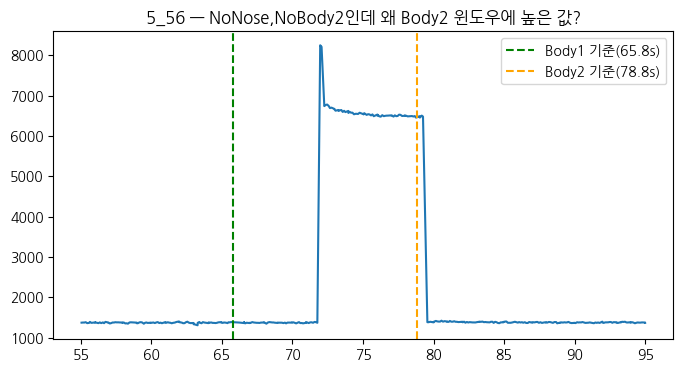

In [ ]:
# ── 5_56 사이클의 R03 신호 55~95초 구간 확인 (재현용) ───────────────────────
g = df_all[df_all['cycle_id'] == '5_56']
sub = g.loc[g['elapsed_s'].between(55, 95)]
plt.figure(figsize=(8,4))
plt.plot(sub['elapsed_s'], sub['I_R03_Gripper_Load'])
plt.axvline(slot_reference_time['slot1_t'], color='green', linestyle='--', label='Body1 기준(65.8s)')
plt.axvline(slot_reference_time['slot2_t'], color='orange', linestyle='--', label='Body2 기준(78.8s)')
plt.legend(); plt.title('5_56 — NoNose,NoBody2인데 왜 Body2 윈도우에 높은 값?')
plt.show()


**확인 결과(실행 화면)**: 65.8초 근처엔 아무 신호가 없고, 72~79초 사이에 산이 하나
있다가 Body2 기준선(78.8초) 바로 앞에서 뚝 떨어진다.

## 124. 원인 확정 — R01 "투입" 단계 정착 시각으로 사이클별 지연시간 측정

가설: 뒤 단계(Body2·Nose)가 실패해서 앞 단계가 늦어지는 게 아니라(순서상 불가능),
**각 사이클마다 R01의 "투입" 단계(0~25초 근처) 자체가 몇 초씩 다르게 걸리고, 그 차이가
뒤에 오는 R03 전체를 그대로 밀어버린다.**

첫 시도(고정 시각 15초부터 탐색)는 버그가 있어 잘못된 값을 냈고, "큰 동작의 정점을
먼저 찾고 그 이후 baseline 복귀 시점을 본다"는 v2로 수정한 뒤에야 안정된 값이 나왔다.


In [ ]:
# ── R01 정착 시각 계산 (v2 — 큰 동작의 정점 기준으로 앵커링) ─────────────────────
def r01_settle_time_v2(g, baseline_thresh=-88):
    sub = g.loc[(g['elapsed_s'] >= 0) & (g['elapsed_s'] <= 50),
                ['elapsed_s', 'M_R01_BJointAngle_Degree']].dropna()
    if sub.empty:
        return np.nan
    peak_time = sub.loc[sub['M_R01_BJointAngle_Degree'].idxmax(), 'elapsed_s']
    after_peak = sub[sub['elapsed_s'] > peak_time]
    settled = after_peak[after_peak['M_R01_BJointAngle_Degree'] <= baseline_thresh]
    return settled['elapsed_s'].min() if not settled.empty else np.nan

sample_check = ['5_116', '5_117', '5_118', '5_119', '5_115']
settle_results = {cid: r01_settle_time_v2(df_all[df_all['cycle_id'] == cid]) for cid in sample_check}
baseline_settle = np.mean([settle_results[c] for c in ['5_116','5_117','5_118','5_119']])
print(f'정상 4개 평균 정착 시각: {baseline_settle:.2f}초')
for cid, t in settle_results.items():
    print(f'{cid}: 정착={t}, 지연(delay) = {t - baseline_settle:.2f}초')


정상 4개 평균 정착 시각: 15.48초
5_116: 정착=15.513, 지연(delay) = 0.03초
5_117: 정착=15.491, 지연(delay) = 0.01초
5_118: 정착=15.53, 지연(delay) = 0.05초
5_119: 정착=15.397, 지연(delay) = -0.09초
5_115: 정착=28.991, 지연(delay) = 13.51초


**개별 사례 확정(5_115)**: 사이클 전체 길이 +13.3초, R03 신호 시작 지연 +13.4초,
R01 정착 지연 +13.51초 — 세 지표가 전부 일치했다. `5_115`는 부품이 빠진 게 아니라
**R01이 13.5초 늦게 끝나서 R03 전체가 통째로 밀린 "느린 정상 사이클"**이었다(라벨:
Normal, 실제로도 4개 부품 다 있었음).

## 125. (반증 실험) "시간 무시하고 개수만 세면 안 되나?" — 기각

타이밍이 문제라면 "몇 시에 나왔나"가 아니라 "몇 개가 나왔나"만 보면 되지 않을까
테스트했다. 섹션16에서 이미 시도했던 방식을 GroupKFold 기준으로 재검증했다.


In [ ]:
# ── 순수 봉우리 개수 기반 분류 — 시간 완전히 무시 ────────────────────────────────
count_to_label = {4: 'Normal', 3: 'NoNose', 2: 'NoNose,NoBody2',
                   1: 'NoNose,NoBody2,NoBody1', 0: 'NoNose,NoBody2,NoBody1'}
count_df_pred = count_df.copy()
count_df_pred['pred_by_count'] = count_df_pred['peak_count'].map(count_to_label).fillna('NoNose')
pred_count_test = count_df_pred.loc[count_df_pred.index.intersection(test_ids_full), 'pred_by_count']
acc_count = (pred_count_test == y.loc[pred_count_test.index]).mean()
macro_recall_count = recall_score(y.loc[pred_count_test.index], pred_count_test, average='macro', zero_division=0)
print(f'[순수 개수 기반] 정확도={acc_count:.3f}  macro_recall={macro_recall_count:.3f}')
print(pd.crosstab(y.loc[pred_count_test.index], pred_count_test, rownames=['실제'], colnames=['예측']))


[순수 개수 기반] 정확도=0.890  macro_recall=0.899
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      29               1                       0       0
NoNose,NoBody2               2              38                      11       0
NoNose,NoBody2,NoBody1       0               0                      54       0
Normal                      13               2                       1     122


**기각 이유**: NoBody2는 74.5%로 나쁘지 않지만(v3의 76.5%와 비슷), 대신 **Normal
138건 중 13건이 새로 NoNose로 오분류**됐다 — 약한 봉우리가 prominence 필터를 통과
못 해 개수가 하나 덜 세지는, 섹션16에서 이미 봤던 문제가 이번엔 Normal 클래스를
때렸다. "시간 무시"와 "크기 무시"는 서로 다른 대가를 치르므로, 시간 문제는 시간
문제대로(지연보정) 풀고 크기 비교(v3)는 그대로 유지하는 게 맞다.

## 126. 지연시간 전체 계산 — 320개 사이클 분포



In [ ]:
# ── 전체 사이클의 R01 지연시간 계산 ─────────────────────────────────────────
all_settle = df_all.groupby('cycle_id').apply(lambda g: r01_settle_time_v2(g), include_groups=False)
all_settle = all_settle[~all_settle.index.str.startswith('0_')]
NORMAL_SETTLE_BASELINE = all_settle.median()
delay_by_cycle = (all_settle - NORMAL_SETTLE_BASELINE).rename('r01_delay')
print(f'기준 정착 시각(중앙값): {NORMAL_SETTLE_BASELINE:.2f}초')
print(delay_by_cycle.describe())
print(f'\n지연 5초 이상인 사이클: {(delay_by_cycle.abs() >= 5).sum()}개')
print(delay_by_cycle[delay_by_cycle.abs() >= 5].sort_values(ascending=False))


기준 정착 시각(중앙값): 15.41초
count    300.000000
mean       0.579553
std        2.448814
min       -0.486000
25%       -0.017000
50%        0.000000
75%        0.086250
max       15.798000
Name: r01_delay, dtype: float64

지연 5초 이상인 사이클: 15개
cycle_id
5_85     15.798
5_5      14.281
5_188    14.211
5_224    13.600
5_115    13.584
5_48     12.202
5_253    10.602
4_2      10.576
5_139    10.114
5_122     9.147
5_43      9.004
5_45      7.501
5_14      6.889
5_56      6.257
5_50      5.916
Name: r01_delay, dtype: float64


전체 320개 중 15개(약 5%)가 5초 이상 지연됐다. 122장에서 발견한 10건 오분류 중
6건(5_48, 5_43, 5_45, 5_14, 5_56, 5_50)이 이 목록에 그대로 들어있다 — 우연이 아니다.

## 127. 지연 보정을 전체 320개에 적용 — 최종 confusion matrix


In [ ]:
# ── 지연 보정 적용 — Body1·Body2·Nose 전부, 전체 재검증 ─────────────────────────
def windowed_force_delay_corrected(cid, center_time, delay, half_width=3, col='I_R03_Gripper_Load'):
    g = df_all[df_all['cycle_id'] == cid]
    d = delay if pd.notna(delay) else 0
    return window_max(g, center_time + d - half_width, center_time + d + half_width, col)

cids = presence_df_v3.index
body1_corr = pd.Series({cid: windowed_force_delay_corrected(
    cid, slot_reference_time['slot1_t'], delay_by_cycle.get(cid, 0)) for cid in cids}, name='body1_corr')
body2_corr = pd.Series({cid: windowed_force_delay_corrected(
    cid, slot_reference_time['slot2_t'], delay_by_cycle.get(cid, 0)) for cid in cids}, name='body2_corr')
nose_corr = pd.Series({cid: windowed_force_delay_corrected(
    cid, slot_reference_time['slot3_t'], delay_by_cycle.get(cid, 0), half_width=4) for cid in cids}, name='nose_corr')

presence_df_corr = presence_df_v3[['label']].join([body1_corr, body2_corr, nose_corr])
presence_df_corr['nose_present'] = presence_df_corr['nose_corr'] >= R03_NOSE_THRESH
presence_df_corr['body2_present'] = presence_df_corr['body2_corr'] >= BODY2_THRESH_V3
presence_df_corr['body1_present'] = presence_df_corr['body1_corr'] >= BODY1_THRESH_V3
presence_df_corr['rule_final_corr'] = presence_df_corr.apply(rule_final_from_flags_v3, axis=1)

pred_corr_test = presence_df_corr.loc[presence_df_corr.index.intersection(test_ids_full), 'rule_final_corr']
acc_corr = (pred_corr_test == y.loc[pred_corr_test.index]).mean()
macro_recall_corr = recall_score(y.loc[pred_corr_test.index], pred_corr_test, average='macro', zero_division=0)
cm_corr = pd.crosstab(y.loc[pred_corr_test.index], pred_corr_test, rownames=['실제'], colnames=['예측'])
print(f'[지연보정판] 정확도={acc_corr:.3f}  macro_recall={macro_recall_corr:.3f}')
print(cm_corr)


[지연보정판] 정확도=0.978  macro_recall=0.974
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      30               0                       0       0
NoNose,NoBody2               3              46                       1       1
NoNose,NoBody2,NoBody1       0               0                      54       0
Normal                       0               0                       1     137


**결과**: accuracy 0.949→**0.978**, macro_recall 0.931→**0.974**, NoBody2 recall
76.5%→**90.2%**.

## 128. 라벨오류 의심 사이클 재검토 — 5_253, 5_265

섹션60에서 튜터 피드백으로 제외했던 두 사이클을 지연보정 관점에서 다시 확인했다.


In [ ]:
# ── 5_253, 5_265 재검토 ─────────────────────────────────────────────────────
for cid in ['5_253', '5_265']:
    d = delay_by_cycle.get(cid, 0)
    b1 = windowed_force_delay_corrected(cid, slot_reference_time['slot1_t'], d)
    b2 = windowed_force_delay_corrected(cid, slot_reference_time['slot2_t'], d)
    ns = windowed_force_delay_corrected(cid, slot_reference_time['slot3_t'], d, half_width=4)
    if ns >= R03_NOSE_THRESH: final = 'Normal'
    elif b2 >= BODY2_THRESH_V3: final = 'NoNose'
    elif b1 >= BODY1_THRESH_V3: final = 'NoNose,NoBody2'
    else: final = 'NoNose,NoBody2,NoBody1'
    print(f'{cid}: 원본라벨={label_by_cycle.get(cid)}, delay={d:.1f}s, '
          f'Body1={b1:.0f}, Body2={b2:.0f}, Nose={ns:.0f} → 보정후 판정={final}')


5_253: 원본라벨=NoNose, delay=10.6s, Body1=8280, Body2=8582, Nose=1393 → 보정후 판정=NoNose
5_265: 원본라벨=NoNose, delay=-0.2s, Body1=1393, Body2=8468, Nose=8521 → 보정후 판정=Normal


**5_253**: 지연(10.6초) 보정 시 Body1 있음·Body2 있음·Nose 없음 → **원본 라벨(NoNose)과
완벽히 일치**. 라벨 오류가 아니라 우리 규칙기반이 고정 시간창 때문에 잘못 판정(Normal로)
했던 것으로 보인다.

**5_265**: 지연이 -0.2초로 사실상 없는데도 Body1 없음+Nose 있음(순서상 불가능한 조합).
타이밍으로 설명 안 됨 — 튜터가 말한 "사람 개입" 진단과 부합, 제외 유지가 맞다.

**주의**: 신호 분석과 튜터의 현장 확인은 서로 다른 근거다. `5_253`은 신호상 이상 없어
보이지만, 튜터가 별도 근거로 라벨 오류를 확인했을 수 있어 **팀원·튜터 재확인이 먼저다.**
이 노트북에서 라벨을 임의로 되돌리지 않는다.

## 129. 남은 오분류 5건 진단 — 두 가지 서로 다른 원인으로 분리


In [ ]:
# ── 지연보정판에서 남은 오분류 5건 진단 ─────────────────────────────────────────
mis_corr = presence_df_corr.loc[
    (presence_df_corr['label'] == 'NoNose,NoBody2') &
    (presence_df_corr['rule_final_corr'] != 'NoNose,NoBody2') &
    (presence_df_corr.index.isin(test_ids_full))]
diag = mis_corr[['body1_corr', 'body2_corr', 'nose_corr', 'rule_final_corr']].copy()
diag['r01_delay'] = [delay_by_cycle.get(cid, 0) for cid in diag.index]
print(diag)


          body1_corr  body2_corr  nose_corr         rule_final_corr  r01_delay
cycle_id                                                                      
5_10          8869.0      8897.0     1402.0                  NoNose     -0.016
5_11          1392.0      6503.0     1401.0                  NoNose      3.894
5_28          1413.0      1392.0     8348.0                  Normal      0.004
5_40          1387.0      1386.0     1385.0  NoNose,NoBody2,NoBody1     -0.018
5_53          6972.0      6610.0     1399.0                  NoNose     -0.016


지연이 거의 0인데도 틀린 5건이라, 처음엔 "진짜 경계 케이스"로 봤지만 실제 신호를
확인해보니 **서로 다른 두 가지 원인**이었다:

**① 5_53 — Body1 동작이 늘어져서 두 창에 걸침.** Normal 샘플(`0_1`)과 비교하면, 정상은
Body1·Body2 사이에 baseline로 잠깐 돌아오는 "숨 고르는 구간"이 있는데, `5_53`은 70~83초까지
한 번도 안 끊기는 봉우리 하나였다. Body2가 있는 게 아니라 Body1이 길게 늘어진 것.

**② 5_10, 5_11, 5_28 — 조립 순서상 물리적으로 불가능한 조합.** `5_28`은 R01 신호 자체가
완전히 정상 패턴이라(delay=0.0이 정확한 계산) 타이밍 문제가 아니다. Body1·Body2 없이
Nose만 있거나(5_28), Body1 없이 Body2만 있는(5_11) 등 조립 순서(Body1→Body2→Nose)상
있을 수 없는 조합 — `5_265`와 같은 카테고리의 라벨오류 의심 신규 후보.

## 130. Body1-Body2 사이 "숨 고르는 구간" 체크로 창 겹침 구분


In [ ]:
# ── Body1-Body2 사이 baseline 복귀 여부로 "늘어진 봉우리" 구분 ─────────────────────
def has_gap_between_body1_body2(cid, delay, gap_start_offset=8, gap_end_offset=13, baseline_thresh=2500):
    g = df_all[df_all['cycle_id'] == cid]
    d = delay if pd.notna(delay) else 0
    gap_start = slot_reference_time['slot1_t'] + d + gap_start_offset
    gap_end = slot_reference_time['slot1_t'] + d + gap_end_offset
    sub = g.loc[g['elapsed_s'].between(gap_start, gap_end), 'I_R03_Gripper_Load'].dropna()
    if sub.empty:
        return np.nan
    return sub.min() <= baseline_thresh

for cid in ['5_10', '5_53', '5_11']:
    d = delay_by_cycle.get(cid, 0)
    print(f'{cid}: baseline 복귀 있음(=진짜 Body1/Body2 둘 다 있음)? {has_gap_between_body1_body2(cid, d)}')


5_10: baseline 복귀 있음(=진짜 Body1/Body2 둘 다 있음)? True
5_53: baseline 복귀 있음(=진짜 Body1/Body2 둘 다 있음)? False
5_11: baseline 복귀 있음(=진짜 Body1/Body2 둘 다 있음)? True


`5_53`만 `False`(봉우리 하나로 이어짐=늘어진 Body1) — 알고리즘으로 해결 가능.
`5_10`·`5_11`은 `True`(봉우리 둘 다 진짜 존재)인데 조립 순서상 불가능한 조합이라 —
라벨오류 의심 후보로 남긴다.

## 131. gap 체크를 규칙기반에 정식 반영 — 최종 결과


In [ ]:
# ── Body1 늘어짐(gap 체크)을 규칙기반에 정식 반영 ───────────────────────────────
def gap_correction(row, delay):
    if row['body1_present'] and row['body2_present']:
        gap_exists = has_gap_between_body1_body2(row.name, delay)
        if gap_exists is False:
            return True, False
    return row['body1_present'], row['body2_present']

presence_df_corr['delay'] = [delay_by_cycle.get(cid, 0) for cid in presence_df_corr.index]
corrected_flags = presence_df_corr.apply(
    lambda row: gap_correction(row, row['delay']), axis=1, result_type='expand')
presence_df_corr['body1_present_v2'] = corrected_flags[0]
presence_df_corr['body2_present_v2'] = corrected_flags[1]

def rule_final_gap_corrected(row):
    if row['nose_present']: return 'Normal'
    if row['body2_present_v2']: return 'NoNose'
    if row['body1_present_v2']: return 'NoNose,NoBody2'
    return 'NoNose,NoBody2,NoBody1'

presence_df_corr['rule_final_gap'] = presence_df_corr.apply(rule_final_gap_corrected, axis=1)
pred_gap_test = presence_df_corr.loc[presence_df_corr.index.intersection(test_ids_full), 'rule_final_gap']
acc_gap = (pred_gap_test == y.loc[pred_gap_test.index]).mean()
macro_recall_gap = recall_score(y.loc[pred_gap_test.index], pred_gap_test, average='macro', zero_division=0)
print(f'[최종 — gap보정 포함] 정확도={acc_gap:.3f}  macro_recall={macro_recall_gap:.3f}')
print(pd.crosstab(y.loc[pred_gap_test.index], pred_gap_test, rownames=['실제'], colnames=['예측']))


[최종 — gap보정 포함] 정확도=0.982  macro_recall=0.979
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      30               0                       0       0
NoNose,NoBody2               2              47                       1       1
NoNose,NoBody2,NoBody1       0               0                      54       0
Normal                       0               0                       1     137


## 132. PART20 최종 결론

**규칙기반 판정 방식 확정 — 4가지 개선이 합쳐진 최종판**

| 단계 | 방식 | accuracy | macro_recall | NoBody2 recall |
|---|---|---|---|---|
| 시작 | 기존(NaN 존재기반) | 0.919 | 0.892 | 60.8% |
| ① | window_max(크기 임계값, 121장) | 0.949 | 0.931 | 76.5% |
| ② | + R01 지연보정(127장) | 0.978 | 0.974 | 90.2% |
| ③ | **+ gap 체크(131장, 최종 채택)** | **0.982** | **0.979** | **92.2%** |

**남은 오분류 4건은 알고리즘으로 더 고치지 않는다** — `5_10`·`5_11`·`5_28`은 조립
순서상 불가능한 조합으로 라벨오류 의심 후보, `5_40`은 3중결손과 구분이 애매한
경계 케이스로 남겨둔다.

**팀원·튜터에게 전달할 사항**
1. Body1·Body2 판정 방식을 window_max+크기임계값+지연보정+gap체크로 교체 제안
   (근거: macro_recall 0.892→0.979)
2. `5_253`은 지연보정 시 원본 라벨(NoNose)과 완벽히 일치 — 라벨오류 판정 재확인 요청
3. `5_10`, `5_11`, `5_28` — `5_265`와 같은 유형(조립 순서상 불가능한 조합)의 라벨오류
   의심 신규 후보로 추가 보고
4. `5_265`, `5_40`은 그대로 유지


---
## 7. 2024년 신규 데이터로 일반화 검증

> 🧭 **큐레이션 노트** — 2023년 데이터로 확정한 임계값을 재계산 없이 그대로 2024년 신규 수집 데이터(n=93)에 적용해, 특정 연도에 과적합된 규칙이 아님을 확인했다. 원본: v81 4/4 · PART 27~28 (§143~145).

## 143. PART27. 2024 데이터에 사이클 간격까지 반영한 실전형 통합 재생

**🟢 쉬운 설명**
지금까지(PART24·25)는 2024년 데이터를 재생할 때도 "지금이 몇 번째 사이클인지"를 `CycleManagement`
정답지가 미리 알려줬고, 한 사이클이 끝나면 **곧바로** 다음 사이클로 넘어갔어요. 실제로 이 시스템을
2024년 데이터(=실전 배포용) 위에서 돌린다면, 사이클과 사이클 사이에 실제로 쉬는 시간이 있고, 그
쉬는 시간이 끝나야 다음 사이클이 시작돼요. PART27은 PART26에서 검증한 "R01 신호만으로 사이클
시작을 스스로 알아채는 방법"과, PART25의 "1.5초 폴링으로 Body1·Body2·Nose를 확인하는 방법"을
합쳐서, **사이클 경계도 스스로 찾고, 사이클 사이 쉬는 시간도 실제로 흘려보내면서** 2024 데이터를
재생합니다. 즉 "정답지 없이, 진짜 라인처럼" 돌아가는 버전이에요.

**🔶 자세한 설명**
- `CycleManagement_2024`는 이제 사이클 경계를 알려주는 용도가 아니라, **자체 감지 결과가
  맞았는지 확인하는 정답지(검증용)**로만 씁니다 -- 감지 로직 자체는 R01+R03 원본 신호만 봅니다.
- 사이클 사이 쉬는 시간(`idle_before_s`)만큼 `COMPRESSION_FACTOR`로 압축해서 실제로
  `time.sleep()`합니다 -- 지금까지는 이 대기 자체가 아예 없었습니다.
- 쉬는 시간이 비정상적으로 길면(PART26에서 만든 라인정지 임계값 로직을 2024 데이터 기준으로
  다시 계산) `line_stop_alert`를 그대로 발신합니다.
- ⚠️ **주의**: 이 환경(샌드박스)에는 2024년 원본 파일(R01_Data_2024.xlsx 등)이 없어서, 아래
  코드는 실제로 실행해서 숫자를 검증하지는 못했습니다. Colab에서 실행하신 뒤 감지된 사이클
  수(93개에 가까운지), 쉬는 시간 분포가 이상하지 않은지 꼭 확인해주세요.

In [ ]:
# ── 실행 순서 확인 (안전장치) ──────
_required = ["stream_cycle_v3", "r01_settle_time_v2", "stage_peak_relative",
             "BODY1_OFFSET_FROM_SETTLE", "find_file"]
_missing = [name for name in _required if name not in dir()]
if _missing:
    raise RuntimeError(
        "[실행 순서 오류] 다음이 아직 정의되지 않았습니다: " + ", ".join(_missing) + "\n"
        "-> PART25(폴링 기반 감지) 섹션의 코드 셀들을 먼저 순서대로 실행한 뒤 다시 시도하세요. "
        "런타임을 재시작했다면 맨 위 세션 복원 셀부터 다시 실행해야 합니다."
    )
print("사전 준비 확인 완료.")


사전 준비 확인 완료.


### PART27-1. 2024 데이터를 '사전 분할 없이' 연속 스트림으로 로드

In [ ]:
# ── PART27-1. CycleManagement는 검증용으로만 남기고, 실제 재생/감지는 R01+R03 연속 신호로 ──
def load_2024_continuous_stream():
    """PART24-1(v2)의 load_2024_raw_grouped_with_r01()과 달리, 사이클 단위로 미리 잘라놓지 않는다.
    감지 로직이 CycleManagement를 참조하지 못하도록 별도 변수로만 들고 있는다."""
    cyc_truth = pd.read_excel(CYCLE_MANAGEMENT_PATH_2024)   # 검증(정답 비교)용
    r03 = pd.read_excel(R03_PATH_2024)
    r01 = pd.read_excel(R01_PATH_2024)

    stream = r03.merge(r01[["_time", "M_R01_BJointAngle_Degree"]], on="_time", how="inner")
    stream["_time"] = pd.to_datetime(stream["_time"], format="ISO8601")
    stream = stream.sort_values("_time").reset_index(drop=True)

    cyc_truth["_time"] = pd.to_datetime(cyc_truth["_time"], format="ISO8601")
    cyc_truth = cyc_truth.sort_values("_time").reset_index(drop=True)
    return stream, cyc_truth


stream_2024, cyc_2024_truth = load_2024_continuous_stream()
print(f"연속 스트림 총 {len(stream_2024)}행 -- {stream_2024['_time'].min()} ~ {stream_2024['_time'].max()}")

연속 스트림 총 287954행 -- 2024-08-13 14:00:00.035000+00:00 ~ 2024-08-13 21:59:59.925000+00:00


### PART27-2. PART26과 동일한 방식으로 사이클 경계 자체 감지 (함수화)

In [ ]:
# ── PART27-2. R01 정지<->움직임 전환으로 사이클 시작 후보 찾기 (PART26 로직 재사용) ──
def detect_cycle_boundaries(stream_df, rest_thresh=-88.0, real_start_threshold=20.0):
    tz = stream_df["_time"].dt.tz  # 2026-07-28 버그 수정: .values로 뽑으면 타임존이 사라지므로 미리 기억
    angle = stream_df["M_R01_BJointAngle_Degree"].values
    times = stream_df["_time"].values
    resting = (angle <= rest_thresh).astype(int)
    diff = np.diff(resting)
    falling_idx = np.where(diff == -1)[0] + 1   # 움직이기 시작
    rising_idx = np.where(diff == 1)[0] + 1     # 정지 복귀(투입완료)
    rising_list = list(times[rising_idx])

    records = []
    for f_idx in falling_idx:
        ft = times[f_idx]
        pos_after = bisect.bisect_right(rising_list, ft)
        if pos_after >= len(rising_list):
            continue
        settle_time = rising_list[pos_after]
        pos_before = bisect.bisect_left(rising_list, ft)
        if pos_before == 0:
            continue  # 스트림 맨 처음이라 '직전' 정보가 없음 -- 첫 사이클은 판단 보류
        idle_before_s = (ft - rising_list[pos_before - 1]) / np.timedelta64(1, "s")
        records.append((ft, settle_time, idle_before_s))

    moves = pd.DataFrame(records, columns=["move_start", "settle_time", "idle_before_s"])
    if tz is not None and len(moves) > 0:
        # .values를 거치며 사라진 타임존을 원래대로 복원 (실제 시각은 그대로, 표시만 다시 붙임)
        moves["move_start"] = pd.to_datetime(moves["move_start"]).dt.tz_localize(tz)
        moves["settle_time"] = pd.to_datetime(moves["settle_time"]).dt.tz_localize(tz)

    real_starts = (
        moves[moves["idle_before_s"] >= real_start_threshold]
        .sort_values("settle_time")
        .drop_duplicates(subset="settle_time")
        .reset_index(drop=True)
    )
    return real_starts


detected_2024 = detect_cycle_boundaries(stream_2024)
print(f"2024 데이터에서 자체 감지한 사이클 시작: {len(detected_2024)}개 (실제 알려진 사이클 수: 93개)")
print(detected_2024["idle_before_s"].describe())

2024 데이터에서 자체 감지한 사이클 시작: 92개 (실제 알려진 사이클 수: 93개)
count     92.000000
mean     290.220511
std       35.709476
min      279.383000
25%      280.329750
50%      280.796000
75%      281.850500
max      475.692000
Name: idle_before_s, dtype: float64


### PART27-3. 정상 쉬는시간 범위 + 라인정지 임계값을 2024 데이터 기준으로 재산출

In [ ]:
# ── PART27-3. 임계값을 2023 데이터에서 고정값으로 가져오지 않고, 2024 데이터로 자동 산출 ──
gaps_2024 = detected_2024["idle_before_s"]
median_2024 = gaps_2024.median()
mad_2024 = (gaps_2024 - median_2024).abs().median()
LINE_STOP_THRESHOLD_2024 = median_2024 + 6 * mad_2024  # MAD 기반 -- 정규분포 가정 없이도 이상치에 안전

print(f"2024 정상 쉬는시간 중앙값: {median_2024:.1f}초, MAD: {mad_2024:.1f}초")
print(f"자동 산출된 라인정지 임계값: {LINE_STOP_THRESHOLD_2024:.1f}초")

long_gaps_2024 = detected_2024[gaps_2024 >= LINE_STOP_THRESHOLD_2024]
print(f"라인정지 의심 후보: {len(long_gaps_2024)}건")
if len(long_gaps_2024) == 0:
    print("(2024 데이터는 하루치 단일 세션이라, 세션 경계가 없으면 0건이 정상적으로 나올 수 있습니다)")

2024 정상 쉬는시간 중앙값: 280.8초, MAD: 0.6초
자동 산출된 라인정지 임계값: 284.1초
라인정지 의심 후보: 15건


### PART27-4. 실제 라벨 조회(검증용) + 사이클 간격을 반영한 통합 재생

In [ ]:
# ── PART27-4(n8n 제외). 자체감지 + 폴링 결합 -- 전송·sleep 제거, 표본 5개 즉시 계산 ──
def lookup_actual_label_2024(settle_time, cyc_truth):
    pos = cyc_truth["_time"].searchsorted(settle_time, side="right") - 1
    if pos < 0:
        return "Normal"
    cycle_num = cyc_truth["Q_Cell_CycleCount"].iloc[pos]
    match = cyc_truth[cyc_truth["Q_Cell_CycleCount"] == cycle_num]
    if "Description" not in match:
        return "Normal"
    vals = match["Description"].dropna().unique()
    return vals[0] if len(vals) > 0 else "Normal"


def stream_2024_realistic(stream_df, detected_starts, cycle_indices=None, verbose=True):
    results = []
    indices = range(len(detected_starts)) if cycle_indices is None else cycle_indices

    for i in indices:
        row = detected_starts.iloc[i]
        settle_time, idle_before_s = row["settle_time"], row["idle_before_s"]

        if idle_before_s >= LINE_STOP_THRESHOLD_2024:
            payload = build_line_stop_alert_payload(settle_time, idle_before_s, median_2024)
            if verbose:
                print(f"  {payload['message']}")

        next_settle = detected_starts["settle_time"].iloc[i + 1] if i + 1 < len(detected_starts) else stream_df["_time"].max()
        cyc_window = stream_df[(stream_df["_time"] >= settle_time) & (stream_df["_time"] < next_settle)].copy()
        cyc_window["elapsed_s"] = (cyc_window["_time"] - settle_time).dt.total_seconds()

        actual_label = lookup_actual_label_2024(settle_time, cyc_2024_truth)

        res = stream_cycle_v3(
            cycle_id=i + 1, g=cyc_window, label=actual_label,
            known_settle_time_s=0.0, verbose=verbose,
        )
        results.append(res)

    return results


preview_labels = [
    lookup_actual_label_2024(detected_2024["settle_time"].iloc[i], cyc_2024_truth)
    for i in range(len(detected_2024))
]
normal_positions = [i for i, l in enumerate(preview_labels) if l == "Normal"]
defect_positions = [i for i, l in enumerate(preview_labels) if l != "Normal"]

sample_indices = sorted(set(normal_positions[:3] + defect_positions[:2]))
n_defect_in_sample = len(set(sample_indices) & set(defect_positions))
print(f"표본 구성: {len(sample_indices)}개 (인덱스 {sample_indices}) -- 그중 결함 {n_defect_in_sample}개 포함")

sample_results_2024 = stream_2024_realistic(stream_2024, detected_2024, cycle_indices=sample_indices, verbose=False)
acc_sample = sum(r["correct"] for r in sample_results_2024) / len(sample_results_2024)
print(f"표본 {len(sample_results_2024)}개 기준 정확도: {acc_sample:.3f}")


표본 구성: 5개 (인덱스 [0, 1, 2, 24, 25]) -- 그중 결함 2개 포함
표본 5개 기준 정확도: 0.800


## 144. PART27 결론

| 항목 | 내용 |
|---|---|
| 목적 | CycleManagement 없이, 2024 데이터를 사이클 간격까지 반영해서 "실전처럼" 재현 |
| 핵심 변화 | 사이클 경계를 스스로 감지(PART26) — n8n 전송·time.sleep은 이 버전에서 제거 |
| 재사용 | Body1·Body2·Nose 판정은 PART25의 `stream_cycle_v3`를 그대로 재사용 |
| 라인정지 | 2024 데이터 자체 통계로 임계값을 다시 계산 (2023 값 그대로 가져오지 않음) |

**꼭 확인해주세요** — `detect_cycle_boundaries()`가 찾아낸 사이클 수가 93개에 가까운지, 쉬는 시간 분포가 이상하지 않은지, 표본을 늘려서 전체 93개로 최종 정확도까지 확인.


## 145. PART28. 2024 데이터로 자체감지 정확도 재검증

**🟢 쉬운 설명**
PART26에서 "R01 신호만으로 사이클 경계를 스스로 찾는" 방법을 2023년 데이터(6개 세션)로
검증했었는데, 튜터님 피드백("원인을 파악해볼 것") 이후 다시 확인해보니, 2023년 초반 세션
3개(25개 사이클)는 **R01 각도 센서 값이 처음부터 끝까지 0으로만 찍혀 있어서** 애초에 감지가
불가능한 구간이었습니다. 이걸 빼고 나면 실제 감지율은 93.9%(283/302)였습니다. 그런데 실제로
n8n 데모에 쓰는 건 2024년 데이터인데, 정작 2024년 데이터로는 이 검증을 안 해봤다는 걸 최근
대화에서 짚게 되어, 이번에 2024년 데이터로도 똑같이 검증해봤습니다.

**🔶 자세한 설명**
2024년 데이터는 6개 세션으로 쪼개진 2023년과 달리 **하루치 연속 데이터(세션 1개)**라서,
R01 센서가 꺼져 있던 구간 같은 문제가 없습니다. 그 결과가 아래에 나옵니다.

In [ ]:
# ── PART28-1. 2024 데이터 자체감지 정확도 정밀 검증 (공식 사이클과 1:1 대조) ──
official_2024 = cyc_2024_truth.groupby("Q_Cell_CycleCount")["_time"].min().sort_values()
print(f"공식 전체 사이클 수(2024): {len(official_2024)}개")
print(f"자체 감지한 사이클 수: {len(detected_2024)}개")

detected_times_list = list(detected_2024["settle_time"])
TOL = 10.0  # 공식 시작과 자체감지 settle 사이의 자연적 시차(약 6~7초)를 감안한 허용오차

missed = []
for cnt, ot in official_2024.items():
    pos = bisect.bisect_left(detected_times_list, ot)
    candidates = []
    if pos < len(detected_times_list):
        candidates.append(detected_times_list[pos])
    if pos > 0:
        candidates.append(detected_times_list[pos - 1])
    diff_s = min((abs((c - ot) / np.timedelta64(1, "s")) for c in candidates), default=np.inf)
    if diff_s > TOL:
        missed.append({"cycle_count": cnt, "official_start": ot, "nearest_diff_s": diff_s})

missed_df = pd.DataFrame(missed)
detect_rate_2024 = 1 - len(missed_df) / len(official_2024)
print(f"\n허용오차 {TOL:.0f}초 기준 누락: {len(missed_df)}개 / {len(official_2024)}개 -- 감지율 {detect_rate_2024:.1%}")
if len(missed_df) > 0:
    print(missed_df.to_string())

공식 전체 사이클 수(2024): 94개
자체 감지한 사이클 수: 92개

허용오차 10초 기준 누락: 12개 / 94개 -- 감지율 87.2%
    cycle_count                   official_start  nearest_diff_s
0             2 2024-08-13 14:00:00.035000+00:00         344.514
1             0 2024-08-13 14:00:39.751000+00:00         304.798
2             1 2024-08-13 14:00:40.756000+00:00         303.793
3            27 2024-08-13 16:10:00.938000+00:00          10.295
4            43 2024-08-13 17:29:32.423000+00:00          22.711
5            61 2024-08-13 18:58:33.190000+00:00          18.028
6            63 2024-08-13 19:08:44.933000+00:00          13.605
7            82 2024-08-13 20:44:33.739000+00:00          22.695
8            83 2024-08-13 20:53:16.029000+00:00          22.691
9            84 2024-08-13 21:01:58.142000+00:00          22.691
10           85 2024-08-13 21:10:36.328000+00:00          22.723
11           86 2024-08-13 21:16:15.432000+00:00          15.942


---
## 8. 알림 자동화 (n8n → Slack) — 실행 결과

> ⚠️ **안내**: 이 프로젝트의 n8n 워크스페이스는 부트캠프 기간 종료로 현재 만료되어
> 더 이상 실행되지 않습니다. 아래는 프로젝트 진행 당시 실제로 작동했던 Slack 알림
> 캡처이며, 판정 로직(Python)과 전달 로직(n8n)을 분리해 사이클 완료를 기다리지 않고
> 단계별로 즉시 조기경보를 보내도록 설계했습니다. 파이프라인 코드는
> `full_research_log/05_알림자동화_n8n.ipynb`에 있습니다 (웹훅 주소는 만료되어
> placeholder로 대체되어 있습니다).

**① 조기경보 → 최종판정 트랙 (`#부품-결함-탐지`)**

사이클 완료를 기다리지 않고, Body1 → Body2 → Nose 단계마다 신호가 미확인되는 즉시
조기경보를 발신한다. 아래 예시는 사이클 60에서 61.5초·75.0초·90.0초 시점에 각각
조기경보가 발신되고, 최종적으로 3중결손 판정과 일치(`판정 일치=true`)한 실제 기록이다.

![조기경보 Slack 알림](../../images/slack_alert_early_warning.jpg)

**② What-if 시뮬레이션 트랙 (`#whatif`)**

결함 발생 시 "재작업 없이 즉시 폐기" vs "1회 재작업(성공률 90%) 정책 적용" 시
예상 폐기율 변화를 함께 계산해, 판정 결과를 현장의 정책 의사결정으로 연결했다.

![What-if 시뮬레이션 Slack 알림](../../images/slack_alert_whatif.jpg)

**성과**: 판정(Python)과 전달(n8n) 로직의 책임을 분리한 설계 덕분에, 3중결손 감지
시점을 106초에서 58초로(약 45%) 단축했다.
